In [60]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import ast
from datetime import datetime
from collections import defaultdict
from scipy.optimize import curve_fit, fsolve

# Directory containing Ramsey_qubit_* PD/text files.
directory_path = r'Z:\Lab Data\Qudit_Ramsey_raw_data\Line_signal_compensation_data\paper_data'

# Directory containing raw JSONL data files named in the PD/text files.
Z_drive_raw_data = r'Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data'
# Z_drive_raw_data = r''  # for compatibility with recent data organization
# User input: edit only this transition for a new run.
target_transition = (0, 3, 2)  # (dm, F, mF)

# Fixed frequency: 2*pi over 10 phase points.
def sine_function(t, A, phi, offset):
    return A * np.cos(2 * np.pi / 10 * t + phi) + offset


def combined_decay(t, A, T2_G, T2_L):
    gaussian_decay = np.exp(-(t / T2_G) ** 2)
    lorentzian_decay = np.exp(-t / T2_L)
    return A * gaussian_decay * lorentzian_decay


def parse_filename(filename):
    pattern = (
        r"^Ramsey_qubit_\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]_"
        r"(?:LT)?WaitTime(\d+(?:\.\d+)?)us_comp_(True|False)_"
        r"(\d{8})_(\d{4})(?:_.*)?\.txt$"
    )
    match = re.search(pattern, filename)
    if not match:
        return None

    m = int(match.group(1))
    F = int(match.group(2))
    mF = int(match.group(3))
    wait_time = float(match.group(4))
    comp_flag = match.group(5) == "True"
    date_str = match.group(6) + match.group(7)
    date_time = datetime.strptime(date_str, "%Y%m%d%H%M")
    return m, F, mF, wait_time, comp_flag, date_time


def extract_raw_data_filenames(file_path):
    with open(file_path, "r") as file:
        lines = file.readlines()
    if not lines:
        return []

    raw_data_filenames_line = lines[-1].strip()
    try:
        parsed = ast.literal_eval(raw_data_filenames_line)
        if isinstance(parsed, (list, tuple)):
            return [str(name).strip().strip("'\"") for name in parsed]
    except (SyntaxError, ValueError):
        pass

    return [
        name.strip().strip("'\"")
        for name in raw_data_filenames_line.strip("[]").split(",")
        if name.strip()
    ]


def _raw_path(raw_filename):
    if os.path.isabs(raw_filename):
        return raw_filename
    return os.path.join(Z_drive_raw_data, raw_filename)


def aggregate_runs_by_phase_index(raw_file_runs):
    """
    raw_file_runs is a list of runs for one wait time. Each run is the ordered
    list of raw files for one phase scan. The return value groups files by phase
    index so repeated datetimes at the same wait time are averaged before fitting.
    """
    if len(raw_file_runs) == 0:
        return []

    run_lengths = [len(run) for run in raw_file_runs]
    if len(set(run_lengths)) > 1:
        print(f"Warning: unequal phase-scan lengths for repeated wait time: {run_lengths}")

    n_phase_points = max(run_lengths)
    phase_groups = []
    for phase_index in range(n_phase_points):
        paths_for_phase = []
        for run in raw_file_runs:
            if phase_index < len(run):
                paths_for_phase.append(run[phase_index])
        phase_groups.append(paths_for_phase)
    return phase_groups


def search_files_by_transition_and_comp(directory, target_transition):
    target_transition = tuple(target_transition)
    raw_runs_by_comp_wait = {False: defaultdict(list), True: defaultdict(list)}
    run_records_by_comp_wait = {False: defaultdict(list), True: defaultdict(list)}
    matched_records = []

    for filename in sorted(os.listdir(directory)):
        if not filename.startswith("Ramsey_qubit"):
            continue

        parsed = parse_filename(filename)
        if parsed is None:
            continue

        m, F, mF, wait_time, comp_flag, date_time = parsed
        if (m, F, mF) != target_transition:
            continue

        file_path = os.path.join(directory, filename)
        raw_data_filenames = extract_raw_data_filenames(file_path)
        raw_data_filepaths = [_raw_path(raw_filename) for raw_filename in raw_data_filenames]

        record = {
            "filename": filename,
            "file_path": file_path,
            "transition": (m, F, mF),
            "wait_time_us": wait_time,
            "comp": comp_flag,
            "date_time": date_time,
            "num_phase_points": len(raw_data_filepaths),
            "raw_data_filepaths": raw_data_filepaths,
        }
        raw_runs_by_comp_wait[comp_flag][wait_time].append(raw_data_filepaths)
        run_records_by_comp_wait[comp_flag][wait_time].append(record)
        matched_records.append(record)

    grouped = {}
    for comp_flag in (False, True):
        wait_to_runs = raw_runs_by_comp_wait[comp_flag]
        wait_time_list = sorted(wait_to_runs.keys())
        raw_file_groups_list = []
        raw_file_runs_list = []
        run_records_list = []
        run_count_by_wait_time = {}

        for wait_time in wait_time_list:
            runs = wait_to_runs[wait_time]
            raw_file_runs_list.append(runs)
            run_records_list.append(run_records_by_comp_wait[comp_flag][wait_time])
            raw_file_groups_list.append(aggregate_runs_by_phase_index(runs))
            run_count_by_wait_time[wait_time] = len(runs)

        grouped[comp_flag] = {
            "comp": comp_flag,
            "wait_time_list": wait_time_list,
            "raw_file_groups_list": raw_file_groups_list,
            "raw_file_runs_list": raw_file_runs_list,
            "run_records_list": run_records_list,
            "run_count_by_wait_time": run_count_by_wait_time,
            "matched_files": [r for r in matched_records if r["comp"] == comp_flag],
        }

    return grouped, target_transition, matched_records


ramsey_data_by_comp, final_params, matched_records = search_files_by_transition_and_comp(
    directory_path,
    target_transition,
)

if len(matched_records) == 0:
    raise ValueError(f"No Ramsey_qubit files matched transition {target_transition} in {directory_path}")

m, F, mF = final_params
print(f"Parameters: m={m}, F={F}, mF={mF}")
print(f"Matched {len(matched_records)} PD files across Comp False/True.")

for comp_flag in (False, True):
    group = ramsey_data_by_comp[comp_flag]
    comp_label = f"Comp {comp_flag}"
    print(f"\n{comp_label}: {len(group['matched_files'])} PD files, {len(group['wait_time_list'])} unique wait times")
    for wait_time, phase_groups in zip(group["wait_time_list"], group["raw_file_groups_list"]):
        run_count = group["run_count_by_wait_time"][wait_time]
        files_per_phase = [len(paths) for paths in phase_groups]
        print(
            f"  Wait time: {wait_time} us | runs aggregated: {run_count} | "
            f"phase points: {len(phase_groups)} | raw files/phase: {files_per_phase}"
        )

# Compatibility defaults for older downstream cells: choose Comp True if present,
# otherwise Comp False. The grouped dictionaries above contain both classes.
active_comp_flag = True if len(ramsey_data_by_comp[True]["wait_time_list"]) > 0 else False
wait_time_list = ramsey_data_by_comp[active_comp_flag]["wait_time_list"]
raw_file_paths_list = ramsey_data_by_comp[active_comp_flag]["raw_file_groups_list"]
print(f"\nactive_comp_flag = {active_comp_flag} for compatibility globals")


Parameters: m=0, F=3, mF=2
Matched 241 PD files across Comp False/True.

Comp False: 92 PD files, 35 unique wait times
  Wait time: 0.0 us | runs aggregated: 4 | phase points: 10 | raw files/phase: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  Wait time: 500.0 us | runs aggregated: 4 | phase points: 10 | raw files/phase: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  Wait time: 1000.0 us | runs aggregated: 3 | phase points: 10 | raw files/phase: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Wait time: 1500.0 us | runs aggregated: 3 | phase points: 10 | raw files/phase: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Wait time: 2000.0 us | runs aggregated: 3 | phase points: 10 | raw files/phase: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Wait time: 2500.0 us | runs aggregated: 3 | phase points: 10 | raw files/phase: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Wait time: 3000.0 us | runs aggregated: 3 | phase points: 10 | raw files/phase: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Wait time: 3500.0 us | runs aggregated: 3 | phase points: 10 | raw files/phase: [3, 3, 3, 3,

In [61]:
import numpy as np
import json
import os


def get_shelving_threshold(counts):
    counts = np.asarray(counts, dtype=float)
    data_sorted = np.sort(counts, axis=None)
    if data_sorted.size == 0:
        return np.nan, data_sorted

    trimmed = data_sorted
    if data_sorted.size > 250:
        candidate = data_sorted[100:-100]
        if candidate.size > 0:
            trimmed = candidate

    if trimmed.size > 1000:
        step = round(trimmed.size / (len(counts) * 0.0250167))
        step = max(step, 1)
        trimmed = trimmed[0:-1:step]

    data_sorted_diff = trimmed[1:-1] - trimmed[0:-2]
    if data_sorted_diff.size == 0:
        threshold = float(np.median(trimmed))
    else:
        data_diff_maxind = int(np.argmax(data_sorted_diff))
        threshold = float(data_sorted_diff[data_diff_maxind] / 2 + trimmed[data_diff_maxind])
    return threshold, trimmed


def _read_raw_counts(file_path):
    arrays = []
    with open(file_path, "r") as file:
        for line in file:
            data = json.loads(line)
            arrays.append(data[0]["0"][:])
    return arrays


def _normalize_raw_data_groups(raw_data_filepaths_or_groups):
    """
    Accepts either the old flat list of raw files or the new grouped format:
      old: [phase0_file, phase1_file, ...]
      new: [[phase0_run0, phase0_run1, ...], [phase1_run0, ...], ...]
    """
    if len(raw_data_filepaths_or_groups) == 0:
        return []

    first = raw_data_filepaths_or_groups[0]
    if isinstance(first, (str, bytes, os.PathLike)):
        return [[path] for path in raw_data_filepaths_or_groups]
    return raw_data_filepaths_or_groups


def _classify_shelving(counts_2d, threshold):
    bool_array = np.asarray(counts_2d) > threshold
    if bool_array.ndim != 2:
        raise ValueError(f"Expected one phase point as a 2D shot/readout array, got shape {bool_array.shape}")

    # Preserve the original notebook's 3-state classification matrix.
    # Recent raw files can have only two readout counts per shot; the third
    # column is still needed to mark shots where readout 0 and 1 are both dark.
    result_width = max(3, bool_array.shape[1])
    result_matrix = np.full((bool_array.shape[0], result_width), False, dtype=bool)
    for row_index in range(bool_array.shape[0]):
        data_bool = bool_array[row_index, :]
        if data_bool.size < 2:
            continue
        if data_bool[0] == False:
            if data_bool[1] == True:
                result_matrix[row_index, 1] = True
            elif data_bool[1] == False:
                result_matrix[row_index, 2] = True
    return result_matrix


def _wilson_interval(num_SD, full_data_array, exp_num):
    full_data_array = np.asarray(full_data_array, dtype=float)
    exp_num = np.asarray(exp_num, dtype=float)
    lower_error = np.full(full_data_array.shape, np.nan, dtype=float)
    upper_error = np.full(full_data_array.shape, np.nan, dtype=float)
    valid = exp_num > 0
    if not np.any(valid):
        return lower_error, upper_error

    p = full_data_array[valid]
    n = exp_num[valid]
    z2 = num_SD ** 2
    denom = 1 + z2 / n
    centre = (p + z2 / (2 * n)) / denom
    radius = np.sqrt((p * (1 - p) * z2) / n + z2 ** 2 / (4 * n ** 2)) / denom
    lower_error[valid] = centre - radius
    upper_error[valid] = centre + radius
    return lower_error, upper_error


def process_raw_data_groups(raw_data_file_groups, ket_index=1, verbose=True):
    """
    Processes one wait time. raw_data_file_groups must be grouped by phase index.
    Repeated datetimes at the same wait time are combined within each phase group
    before producing one ket value per phase point.
    """
    raw_data_file_groups = _normalize_raw_data_groups(raw_data_file_groups)
    if len(raw_data_file_groups) == 0:
        return [], np.array([]), np.array([])

    phase_counts_groups = []
    for phase_group in raw_data_file_groups:
        phase_counts = []
        for file_path in phase_group:
            phase_counts.extend(_read_raw_counts(file_path))
        if len(phase_counts) == 0:
            phase_counts = list(np.full((100, 4), 40))
        phase_counts_groups.append(np.asarray(phase_counts))

    flat_hist_data = np.concatenate([phase_counts.reshape(-1) for phase_counts in phase_counts_groups])
    threshold, _ = get_shelving_threshold(flat_hist_data)

    ket_data = []
    exp_num_list = []
    for phase_counts in phase_counts_groups:
        result_matrix = _classify_shelving(phase_counts, threshold)
        rows_with_any_true = result_matrix.any(axis=1)
        filtered_data = result_matrix[rows_with_any_true]

        if filtered_data.size == 0 or filtered_data.shape[1] <= ket_index:
            ket_data.append(np.nan)
            exp_num_list.append(0)
            continue

        ket_data.append(float(np.mean(filtered_data, axis=0)[ket_index]))
        exp_num_list.append(int(filtered_data.shape[0]))

    if verbose:
        print(f"threshold={threshold:.3f}, exp_num_list={exp_num_list}")
    lower_error, upper_error = _wilson_interval(1, np.array(ket_data), np.array(exp_num_list))
    return ket_data, lower_error, upper_error


def process_all_wait_times_in_lists(wait_time_list, raw_file_groups_list, ket_index=1):
    processed_wait_times = []
    ket_data_list = []
    lower_error_list = []
    upper_error_list = []

    for wait_time, raw_file_groups in sorted(zip(wait_time_list, raw_file_groups_list), key=lambda x: x[0]):
        ket_data, lower_error, upper_error = process_raw_data_groups(raw_file_groups, ket_index=ket_index)
        ket_data_arr = np.array(ket_data, dtype=float)
        final_lower_error = np.abs(ket_data_arr - np.array(lower_error, dtype=float))
        final_upper_error = np.abs(np.array(upper_error, dtype=float) - ket_data_arr)

        processed_wait_times.append(wait_time)
        ket_data_list.append(ket_data)
        lower_error_list.append(final_lower_error)
        upper_error_list.append(final_upper_error)

    return processed_wait_times, ket_data_list, lower_error_list, upper_error_list



def process_individual_runs_for_comp_group(group, ket_index=1):
    individual_runs_by_wait_time = []

    for wait_time, raw_file_runs, run_records in zip(
        group.get("wait_time_list", []),
        group.get("raw_file_runs_list", []),
        group.get("run_records_list", []),
    ):
        run_results = []
        for run_index, raw_file_run in enumerate(raw_file_runs):
            raw_file_groups = [[path] for path in raw_file_run]
            ket_data, lower_error, upper_error = process_raw_data_groups(
                raw_file_groups,
                ket_index=ket_index,
                verbose=False,
            )
            ket_data_arr = np.array(ket_data, dtype=float)
            final_lower_error = np.abs(ket_data_arr - np.array(lower_error, dtype=float))
            final_upper_error = np.abs(np.array(upper_error, dtype=float) - ket_data_arr)

            record = run_records[run_index] if run_index < len(run_records) else {}
            date_time = record.get("date_time")
            label = date_time.strftime("%Y%m%d_%H%M") if date_time is not None else f"run {run_index + 1}"

            run_results.append(
                {
                    "wait_time_us": wait_time,
                    "run_index": run_index,
                    "label": label,
                    "ket_data": ket_data,
                    "lower_error": final_lower_error,
                    "upper_error": final_upper_error,
                    "record": record,
                }
            )
        individual_runs_by_wait_time.append(run_results)

    return individual_runs_by_wait_time

def process_all_comp_groups(ramsey_data_by_comp, ket_index=1):
    processed_data_by_comp = {}
    for comp_flag in (False, True):
        group = ramsey_data_by_comp[comp_flag]
        if len(group["wait_time_list"]) == 0:
            processed_data_by_comp[comp_flag] = {
                "processed_wait_times": [],
                "ket_data_list": [],
                "lower_error_list": [],
                "upper_error_list": [],
                "individual_runs_by_wait_time": [],
            }
            continue

        print(f"\nProcessing Comp {comp_flag}")
        processed_wait_times, ket_data_list, lower_error_list, upper_error_list = process_all_wait_times_in_lists(
            group["wait_time_list"],
            group["raw_file_groups_list"],
            ket_index=ket_index,
        )
        individual_runs_by_wait_time = process_individual_runs_for_comp_group(group, ket_index=ket_index)
        processed_data_by_comp[comp_flag] = {
            "processed_wait_times": processed_wait_times,
            "ket_data_list": ket_data_list,
            "lower_error_list": lower_error_list,
            "upper_error_list": upper_error_list,
            "individual_runs_by_wait_time": individual_runs_by_wait_time,
        }
    return processed_data_by_comp


processed_data_by_comp = process_all_comp_groups(ramsey_data_by_comp, ket_index=1)

active_processed = processed_data_by_comp[active_comp_flag]
wait_time_list = active_processed["processed_wait_times"]
processed_wait_times = active_processed["processed_wait_times"]
ket_data_list = active_processed["ket_data_list"]
lower_error_list = active_processed["lower_error_list"]
upper_error_list = active_processed["upper_error_list"]

print("\nProcessed data summary:")
for comp_flag in (False, True):
    data = processed_data_by_comp[comp_flag]
    print(f"Comp {comp_flag}: {len(data['processed_wait_times'])} wait times")
    for wt, ket_vals in zip(data["processed_wait_times"], data["ket_data_list"]):
        print(f"  Wait Time: {wt} us | phase points: {len(ket_vals)} | ket_data: {ket_vals}")



Processing Comp False
threshold=9.500, exp_num_list=[383, 380, 389, 389, 382, 385, 386, 374, 383, 387]
threshold=10.500, exp_num_list=[285, 292, 295, 286, 285, 288, 290, 283, 288, 286]
threshold=9.500, exp_num_list=[295, 290, 283, 290, 288, 290, 292, 293, 291, 288]
threshold=12.000, exp_num_list=[293, 290, 293, 292, 295, 294, 298, 291, 297, 297]
threshold=10.000, exp_num_list=[298, 296, 294, 291, 294, 296, 293, 296, 294, 294]
threshold=9.500, exp_num_list=[296, 294, 294, 295, 293, 293, 293, 295, 296, 293]
threshold=9.500, exp_num_list=[291, 291, 297, 293, 294, 293, 294, 297, 297, 299]
threshold=11.000, exp_num_list=[295, 295, 297, 293, 297, 296, 292, 294, 298, 292]
threshold=10.000, exp_num_list=[294, 298, 296, 295, 293, 295, 296, 296, 293, 296]
threshold=11.000, exp_num_list=[294, 297, 296, 297, 294, 297, 292, 292, 296, 291]
threshold=11.000, exp_num_list=[291, 291, 298, 295, 296, 296, 296, 295, 295, 297]
threshold=11.500, exp_num_list=[296, 292, 294, 295, 289, 294, 293, 292, 294, 29


Fitting phase scans for Comp False


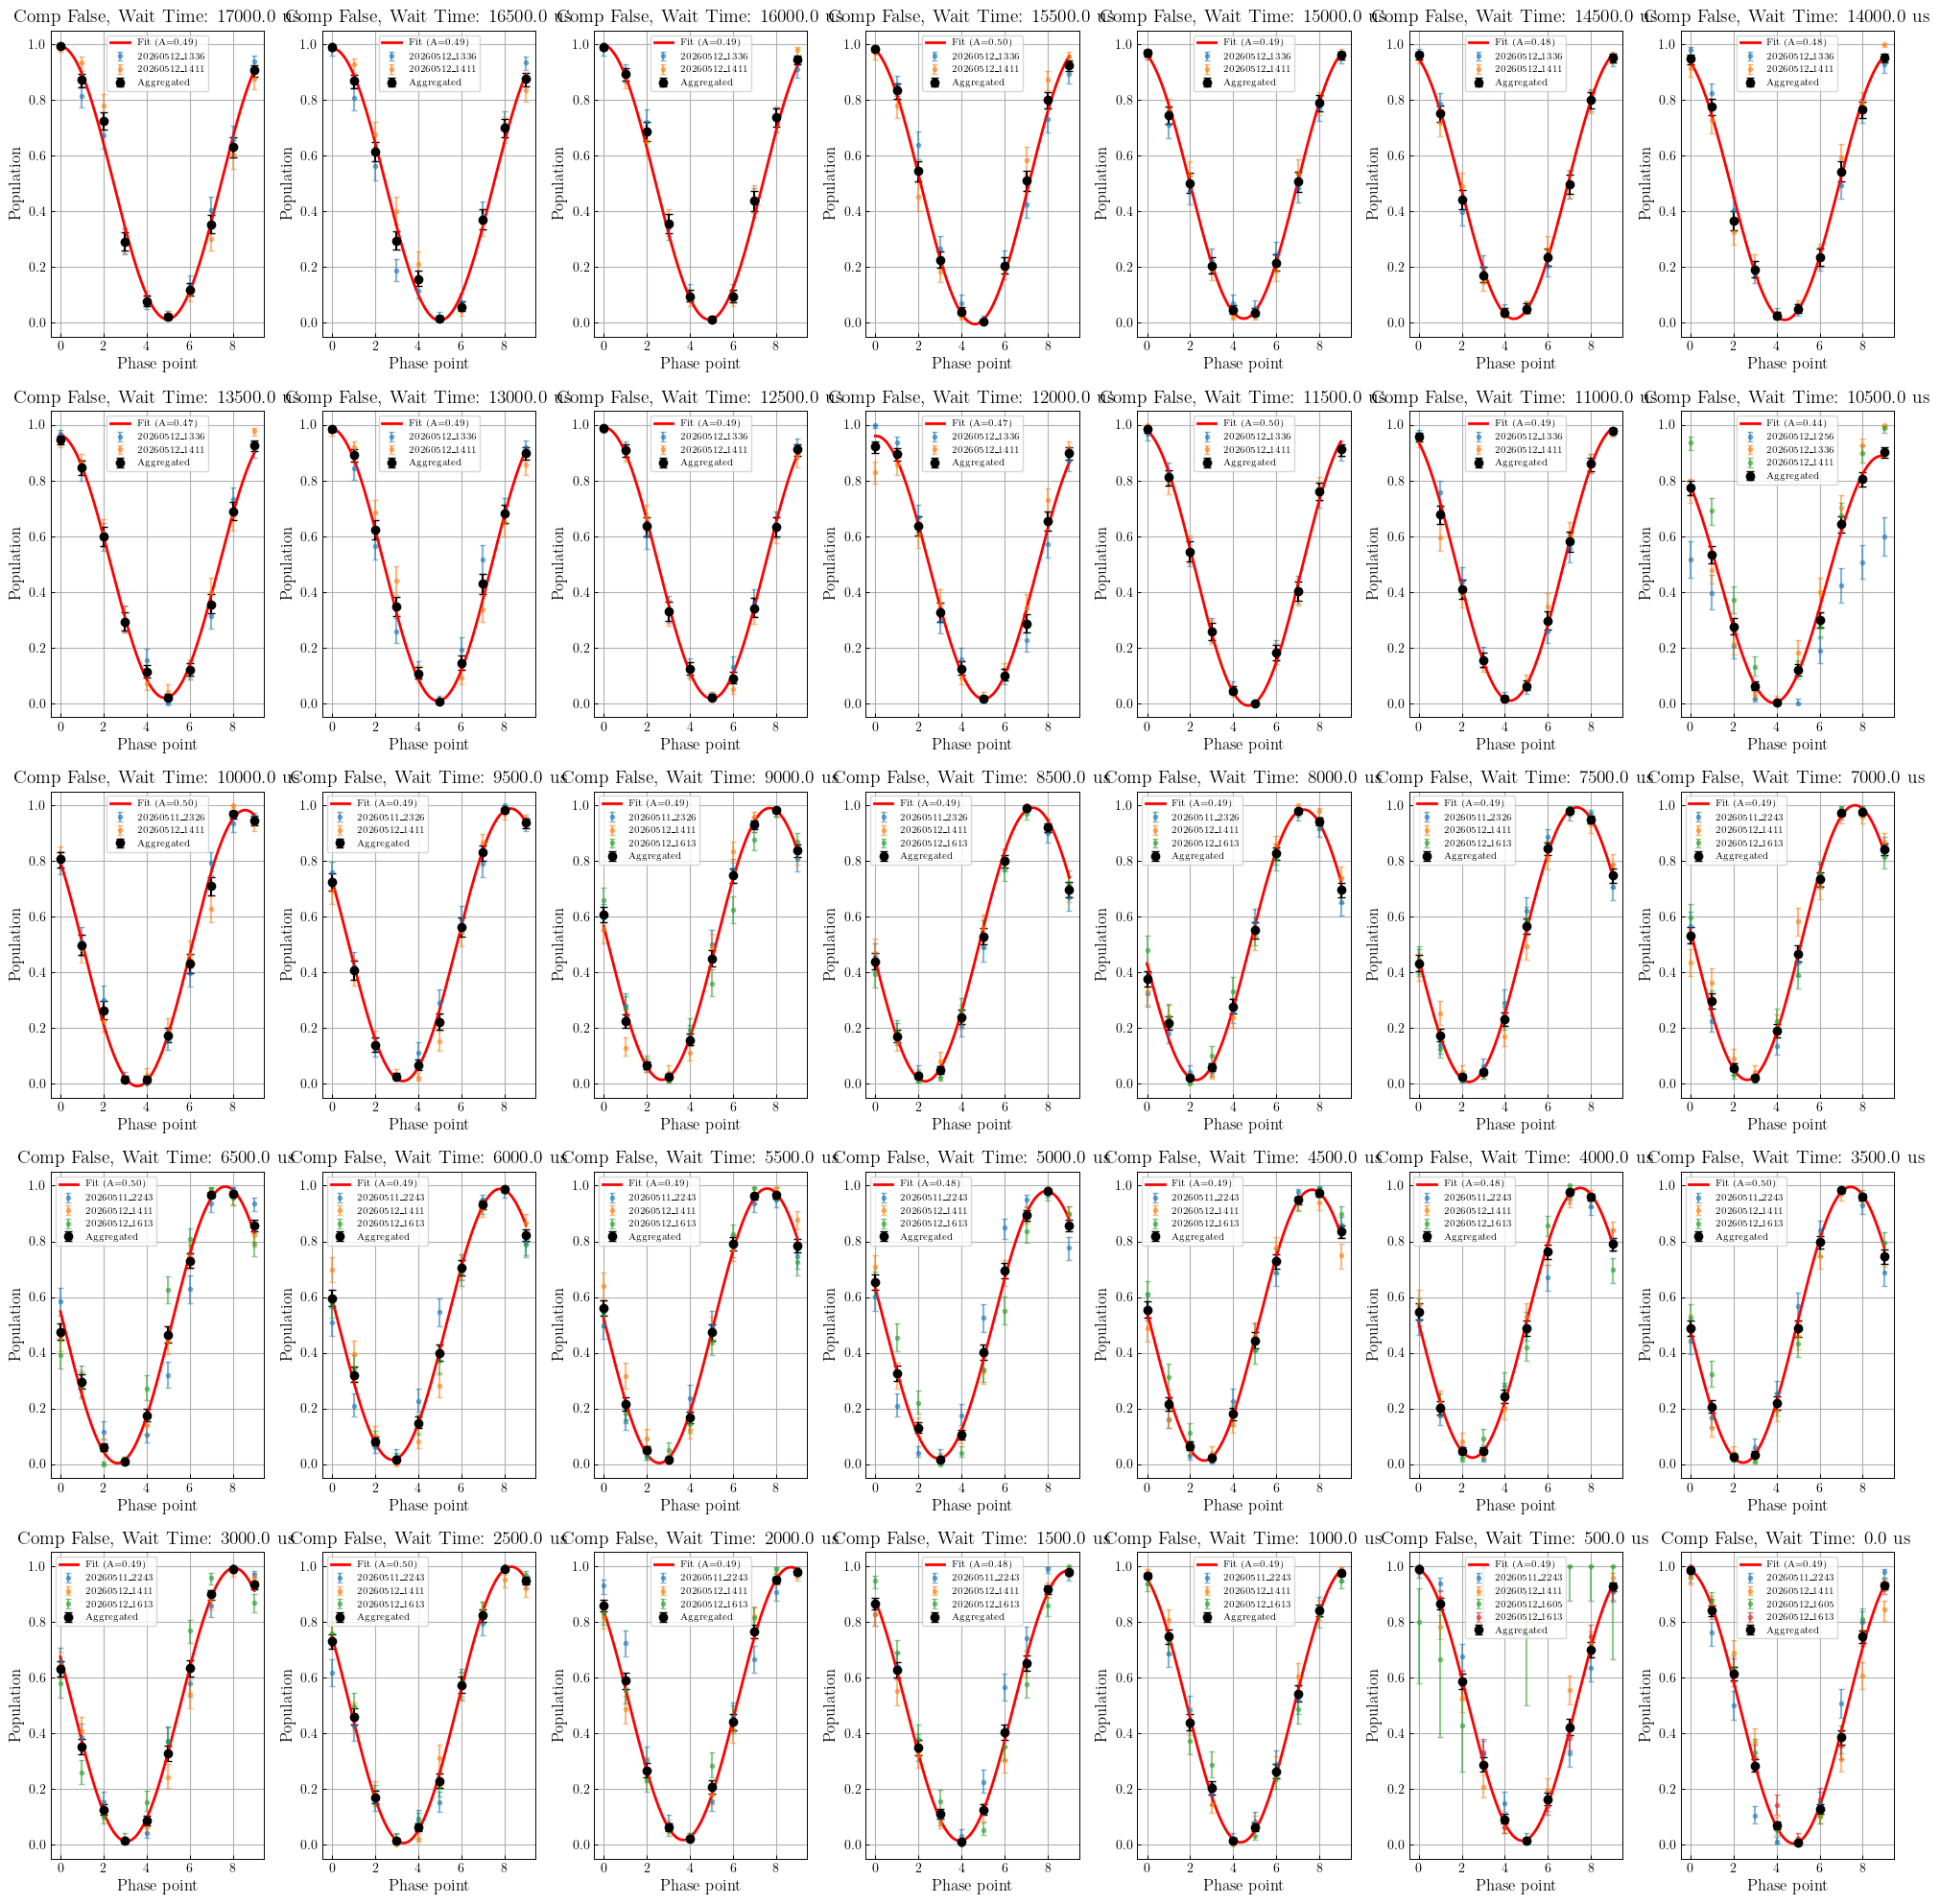


Fitting phase scans for Comp True


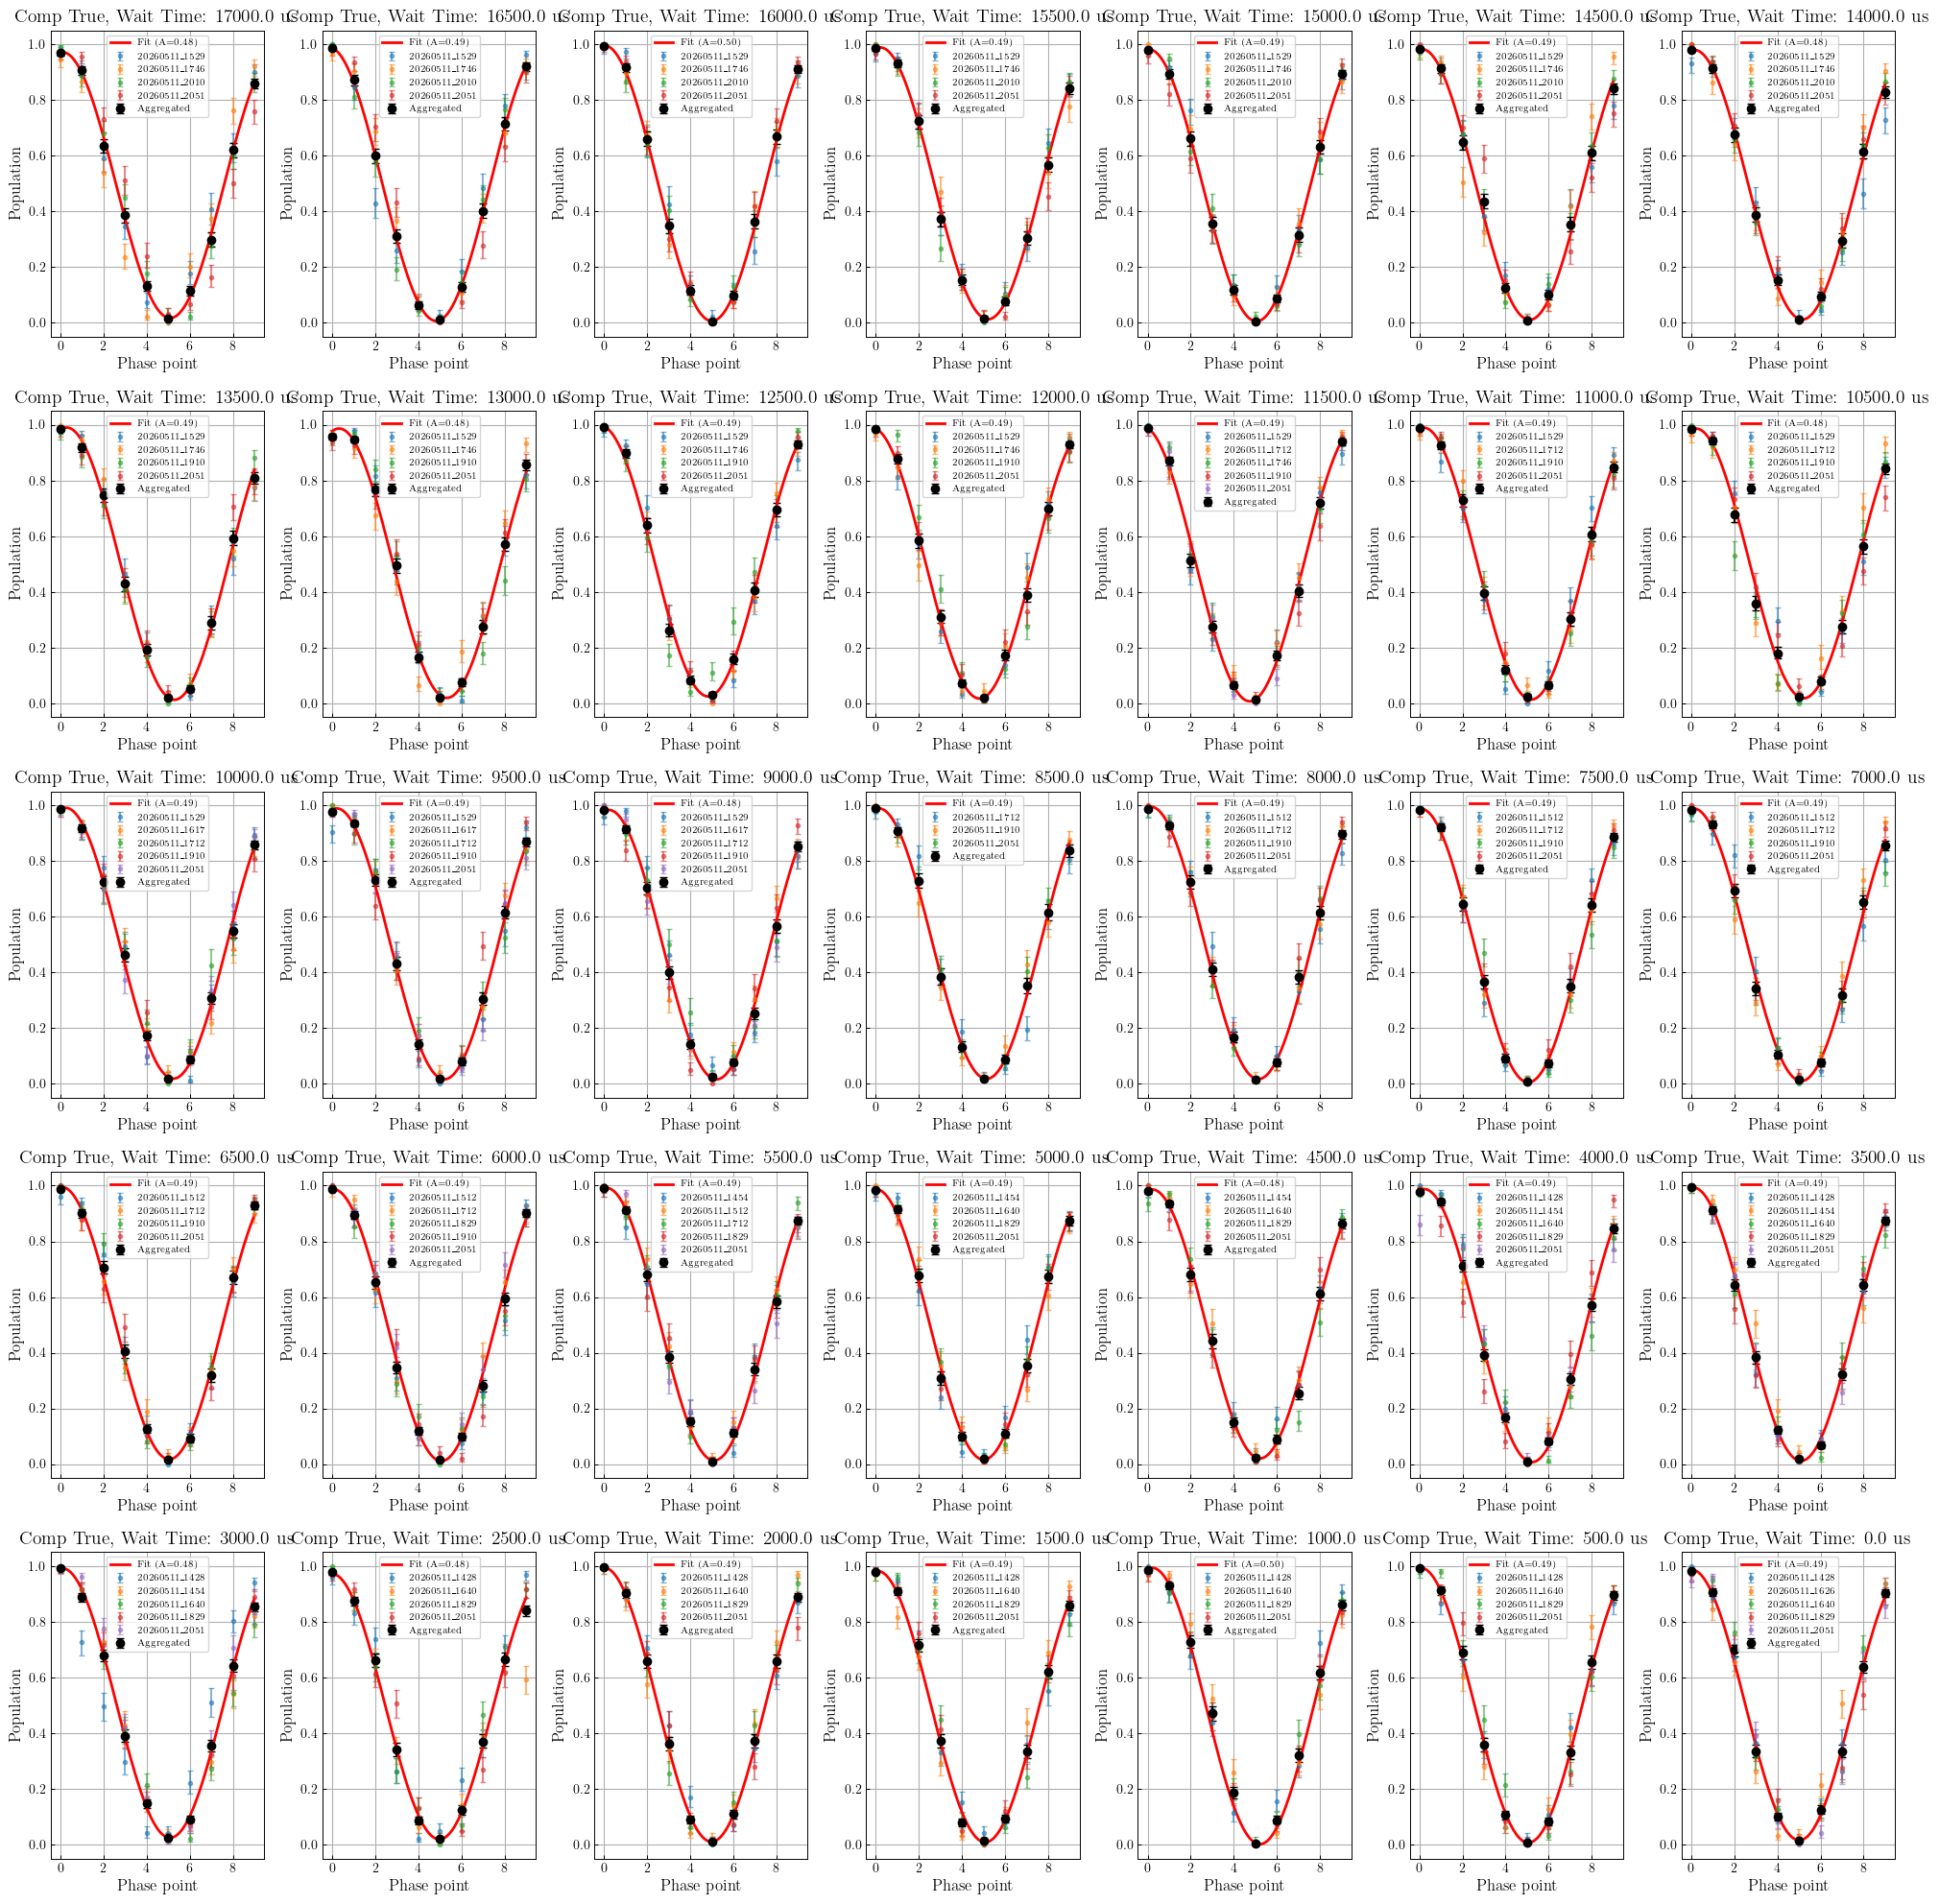

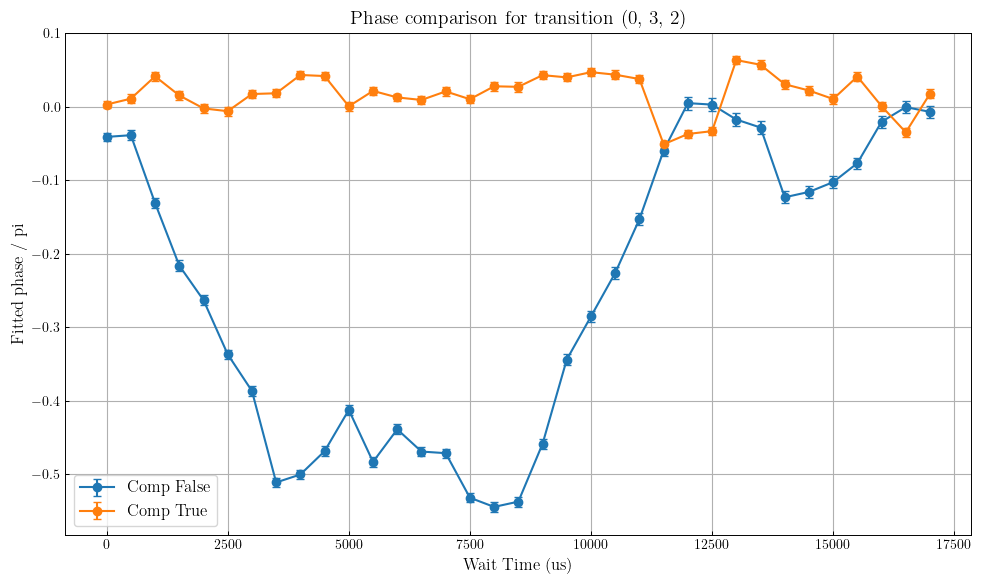


Fitted phase results:

Comp False
  Wait Time: 0.0 us
    Params (A, phi, offset) = 0.493, -0.128, 0.497
    Amplitude (2*|A|) = 0.986 +/- 0.007
    Phase = -0.128 +/- 0.018
  Wait Time: 500.0 us
    Params (A, phi, offset) = 0.489, -0.121, 0.503
    Amplitude (2*|A|) = 0.979 +/- 0.009
    Phase = -0.121 +/- 0.022
  Wait Time: 1000.0 us
    Params (A, phi, offset) = 0.494, -0.411, 0.502
    Amplitude (2*|A|) = 0.989 +/- 0.010
    Phase = -0.411 +/- 0.020
  Wait Time: 1500.0 us
    Params (A, phi, offset) = 0.485, -0.678, 0.498
    Amplitude (2*|A|) = 0.970 +/- 0.009
    Phase = -0.678 +/- 0.022
  Wait Time: 2000.0 us
    Params (A, phi, offset) = 0.490, -0.826, 0.506
    Amplitude (2*|A|) = 0.980 +/- 0.010
    Phase = -0.826 +/- 0.020
  Wait Time: 2500.0 us
    Params (A, phi, offset) = 0.496, -1.058, 0.501
    Amplitude (2*|A|) = 0.992 +/- 0.009
    Phase = -1.058 +/- 0.020
  Wait Time: 3000.0 us
    Params (A, phi, offset) = 0.491, -1.214, 0.502
    Amplitude (2*|A|) = 0.982 +/- 0.0

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def sine_function(t, A, phi, offset):
    return A * np.cos(2 * np.pi / 10 * t - phi) + offset


def fit_sine_curve(ket_data, lower_error, upper_error):
    ket_data = np.array(ket_data, dtype=float)
    lower_error = np.array(lower_error, dtype=float)
    upper_error = np.array(upper_error, dtype=float)

    if len(ket_data) == 5:
        t = 2 * np.arange(len(ket_data))
    else:
        t = np.arange(len(ket_data))

    valid_indices = np.isfinite(ket_data) & np.isfinite(lower_error) & np.isfinite(upper_error)
    if np.count_nonzero(valid_indices) < 4:
        return None, None

    t_valid = t[valid_indices]
    ket_data_valid = ket_data[valid_indices]
    lower_error_valid = lower_error[valid_indices]
    upper_error_valid = upper_error[valid_indices]

    sigma = (upper_error_valid + lower_error_valid) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    A0 = (np.max(ket_data_valid) - np.min(ket_data_valid)) / 2
    A0 = float(np.clip(A0, 1e-6, 0.5))
    offset0 = float(np.clip(np.mean(ket_data_valid), 0.0, 1.0))
    initial_guess = [A0, 0.0, offset0]

    try:
        params, covariance = curve_fit(
            sine_function,
            t_valid,
            ket_data_valid,
            p0=initial_guess,
            sigma=sigma,
            absolute_sigma=True,
            maxfev=10000,
            bounds=([0.0, -np.pi, 0.0], [0.5, np.pi, 1.0]),
        )
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            errors = [err if np.isfinite(err) else None for err in errors]
        else:
            errors = [None] * len(params)
        return params, errors
    except RuntimeError:
        return None, None


def fit_all_wait_times_to_sine_in_lists(wait_time_list, ket_data_list, lower_error_list, upper_error_list):
    fit_wait_times_list = []
    fit_params_list = []
    fit_amplitudes_list = []
    fit_amplitude_errors_list = []
    fit_phases_list = []
    fit_phase_errors_list = []

    for wt, kd, le, ue in zip(wait_time_list, ket_data_list, lower_error_list, upper_error_list):
        params, errors = fit_sine_curve(kd, le, ue)
        fit_wait_times_list.append(wt)

        if params is not None and errors is not None and errors[0] is not None:
            A, phi, offset = params
            amplitude = 2.0 * abs(A)
            amplitude_error = 2.0 * errors[0] if errors[0] is not None else None
            phase_error = errors[1]

            fit_params_list.append(params)
            fit_amplitudes_list.append(amplitude)
            fit_amplitude_errors_list.append(amplitude_error)
            fit_phases_list.append(phi)
            fit_phase_errors_list.append(phase_error)
        else:
            fit_params_list.append([None, None, None])
            fit_amplitudes_list.append(None)
            fit_amplitude_errors_list.append(None)
            fit_phases_list.append(None)
            fit_phase_errors_list.append(None)

    return (
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list,
    )


def plot_sine_fits_in_lists(
    wait_time_list,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    fit_params_list,
    comp_flag,
    individual_runs_by_wait_time=None,
):
    num_plots = len(wait_time_list)
    if num_plots == 0:
        print(f"Comp {comp_flag}: no phase scans to plot.")
        return

    num_columns = min(7, num_plots)
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows), squeeze=False)
    axes = axes.flatten()
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [f"C{i}" for i in range(10)])

    plot_indices = list(range(num_plots))[::-1]
    for ax_index, data_index in enumerate(plot_indices):
        wt = wait_time_list[data_index]
        kd = np.array(ket_data_list[data_index], dtype=float)
        le = np.array(lower_error_list[data_index], dtype=float)
        ue = np.array(upper_error_list[data_index], dtype=float)
        params = fit_params_list[data_index]
        t = 2 * np.arange(len(kd)) if len(kd) == 5 else np.arange(len(kd))
        valid = np.isfinite(kd) & np.isfinite(le) & np.isfinite(ue)

        ax = axes[ax_index]

        if individual_runs_by_wait_time is not None and data_index < len(individual_runs_by_wait_time):
            for run_index, run in enumerate(individual_runs_by_wait_time[data_index]):
                run_kd = np.array(run["ket_data"], dtype=float)
                run_le = np.array(run["lower_error"], dtype=float)
                run_ue = np.array(run["upper_error"], dtype=float)
                run_t = 2 * np.arange(len(run_kd)) if len(run_kd) == 5 else np.arange(len(run_kd))
                run_valid = np.isfinite(run_kd) & np.isfinite(run_le) & np.isfinite(run_ue)
                if not np.any(run_valid):
                    continue

                color = colors[run_index % len(colors)]
                ax.errorbar(
                    run_t[run_valid],
                    run_kd[run_valid],
                    yerr=[np.abs(run_le[run_valid]), np.abs(run_ue[run_valid])],
                    fmt="o",
                    markersize=3,
                    capsize=2,
                    alpha=0.55,
                    color=color,
                    ecolor=color,
                    label=run["label"],
                )

        ax.errorbar(
            t[valid],
            kd[valid],
            yerr=[np.abs(le[valid]), np.abs(ue[valid])],
            fmt="o",
            markersize=6,
            capsize=3,
            color="black",
            ecolor="black",
            label="Aggregated",
        )

        A, phi, offset = params
        if A is not None and np.any(valid):
            t_fit = np.linspace(t[valid].min(), t[valid].max(), 400)
            fit_curve = sine_function(t_fit, A, phi, offset)
            ax.plot(t_fit, fit_curve, color="red", linewidth=2.0, label=f"Fit (A={A:.2f})")

        ax.set_title(f"Comp {comp_flag}, Wait Time: {wt} us")
        ax.set_xlabel("Phase point")
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel("Population")
        ax.grid()
        ax.legend(fontsize=7)

    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.savefig(f"laser_noise_phase_scans_comp_{str(comp_flag).lower()}.png", dpi=300)
    plt.show()

def fit_phase_for_all_comp_groups(processed_data_by_comp, do_plot=True):
    phase_fit_results_by_comp = {}
    for comp_flag in (False, True):
        data = processed_data_by_comp[comp_flag]
        wait_times = data["processed_wait_times"]
        if len(wait_times) == 0:
            phase_fit_results_by_comp[comp_flag] = {
                "fit_wait_times_list": [],
                "fit_params_list": [],
                "fit_amplitudes_list": [],
                "fit_amplitude_errors_list": [],
                "fit_phases_list": [],
                "fit_phase_errors_list": [],
            }
            continue

        print(f"\nFitting phase scans for Comp {comp_flag}")
        (
            fit_wait_times_list,
            fit_params_list,
            fit_amplitudes_list,
            fit_amplitude_errors_list,
            fit_phases_list,
            fit_phase_errors_list,
        ) = fit_all_wait_times_to_sine_in_lists(
            wait_times,
            data["ket_data_list"],
            data["lower_error_list"],
            data["upper_error_list"],
        )

        phase_fit_results_by_comp[comp_flag] = {
            "fit_wait_times_list": fit_wait_times_list,
            "fit_params_list": fit_params_list,
            "fit_amplitudes_list": fit_amplitudes_list,
            "fit_amplitude_errors_list": fit_amplitude_errors_list,
            "fit_phases_list": fit_phases_list,
            "fit_phase_errors_list": fit_phase_errors_list,
        }

        if do_plot:
            plot_sine_fits_in_lists(
                wait_times,
                data["ket_data_list"],
                data["lower_error_list"],
                data["upper_error_list"],
                fit_params_list,
                comp_flag,
                individual_runs_by_wait_time=data.get("individual_runs_by_wait_time"),
            )

    return phase_fit_results_by_comp


phase_fit_results_by_comp = fit_phase_for_all_comp_groups(processed_data_by_comp, do_plot=True)

active_phase_fit = phase_fit_results_by_comp[active_comp_flag]
fit_wait_times_list = active_phase_fit["fit_wait_times_list"]
fit_params_list = active_phase_fit["fit_params_list"]
fit_amplitudes_list = active_phase_fit["fit_amplitudes_list"]
fit_amplitude_errors_list = active_phase_fit["fit_amplitude_errors_list"]
fit_phases_list = active_phase_fit["fit_phases_list"]
fit_phase_errors_list = active_phase_fit["fit_phase_errors_list"]

def plot_phase_comparison_by_comp(phase_fit_results_by_comp, use_modulo=False):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {False: "C0", True: "C1"}

    plotted_any = False
    for comp_flag in (False, True):
        result = phase_fit_results_by_comp[comp_flag]
        wait_times = np.array(result["fit_wait_times_list"], dtype=float)
        phases = np.array([np.nan if p is None else p for p in result["fit_phases_list"]], dtype=float)
        phase_errors = np.array([np.nan if e is None else e for e in result["fit_phase_errors_list"]], dtype=float)

        valid = np.isfinite(wait_times) & np.isfinite(phases) & np.isfinite(phase_errors)
        if not np.any(valid):
            print(f"Comp {comp_flag}: no finite phase points for comparison plot.")
            continue

        wait_times = wait_times[valid]
        phases = phases[valid]
        phase_errors = phase_errors[valid]
        order = np.argsort(wait_times)
        wait_times = wait_times[order]
        phases = phases[order]
        phase_errors = phase_errors[order]

        if use_modulo:
            y = np.mod(phases, 2 * np.pi) / np.pi
            yerr = phase_errors / np.pi
            ylabel = "Fitted phase mod 2pi / pi"
        else:
            y = phases / np.pi
            yerr = phase_errors / np.pi
            ylabel = "Fitted phase / pi"

        ax.errorbar(
            wait_times,
            y,
            yerr=yerr,
            fmt="o-",
            capsize=3,
            color=colors[comp_flag],
            ecolor=colors[comp_flag],
            label=f"Comp {comp_flag}",
        )
        plotted_any = True

    if not plotted_any:
        return None

    ax.set_xlabel("Wait Time (us)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Phase comparison for transition {target_transition}")
    ax.grid()
    ax.legend()
    plt.tight_layout()
    plt.savefig("phase_comparison_comp_false_true.png", dpi=300)
    plt.show()
    return ax


plot_phase_comparison_by_comp(phase_fit_results_by_comp, use_modulo=False)

print("\nFitted phase results:")
for comp_flag in (False, True):
    result = phase_fit_results_by_comp[comp_flag]
    print(f"\nComp {comp_flag}")
    for i, wt in enumerate(result["fit_wait_times_list"]):
        A, phi, offset = result["fit_params_list"][i]
        amp = result["fit_amplitudes_list"][i]
        amp_err = result["fit_amplitude_errors_list"][i]
        phase = result["fit_phases_list"][i]
        phase_err = result["fit_phase_errors_list"][i]
        if A is None:
            print(f"  Wait Time: {wt} us | phase fit failed")
        else:
            print(f"  Wait Time: {wt} us")
            print(f"    Params (A, phi, offset) = {A:.3f}, {phi:.3f}, {offset:.3f}")
            print(f"    Amplitude (2*|A|) = {amp:.3f} +/- {amp_err:.3f}")
            print(f"    Phase = {phase:.3f} +/- {phase_err:.3f}")



Fitting detuning scans for Comp False


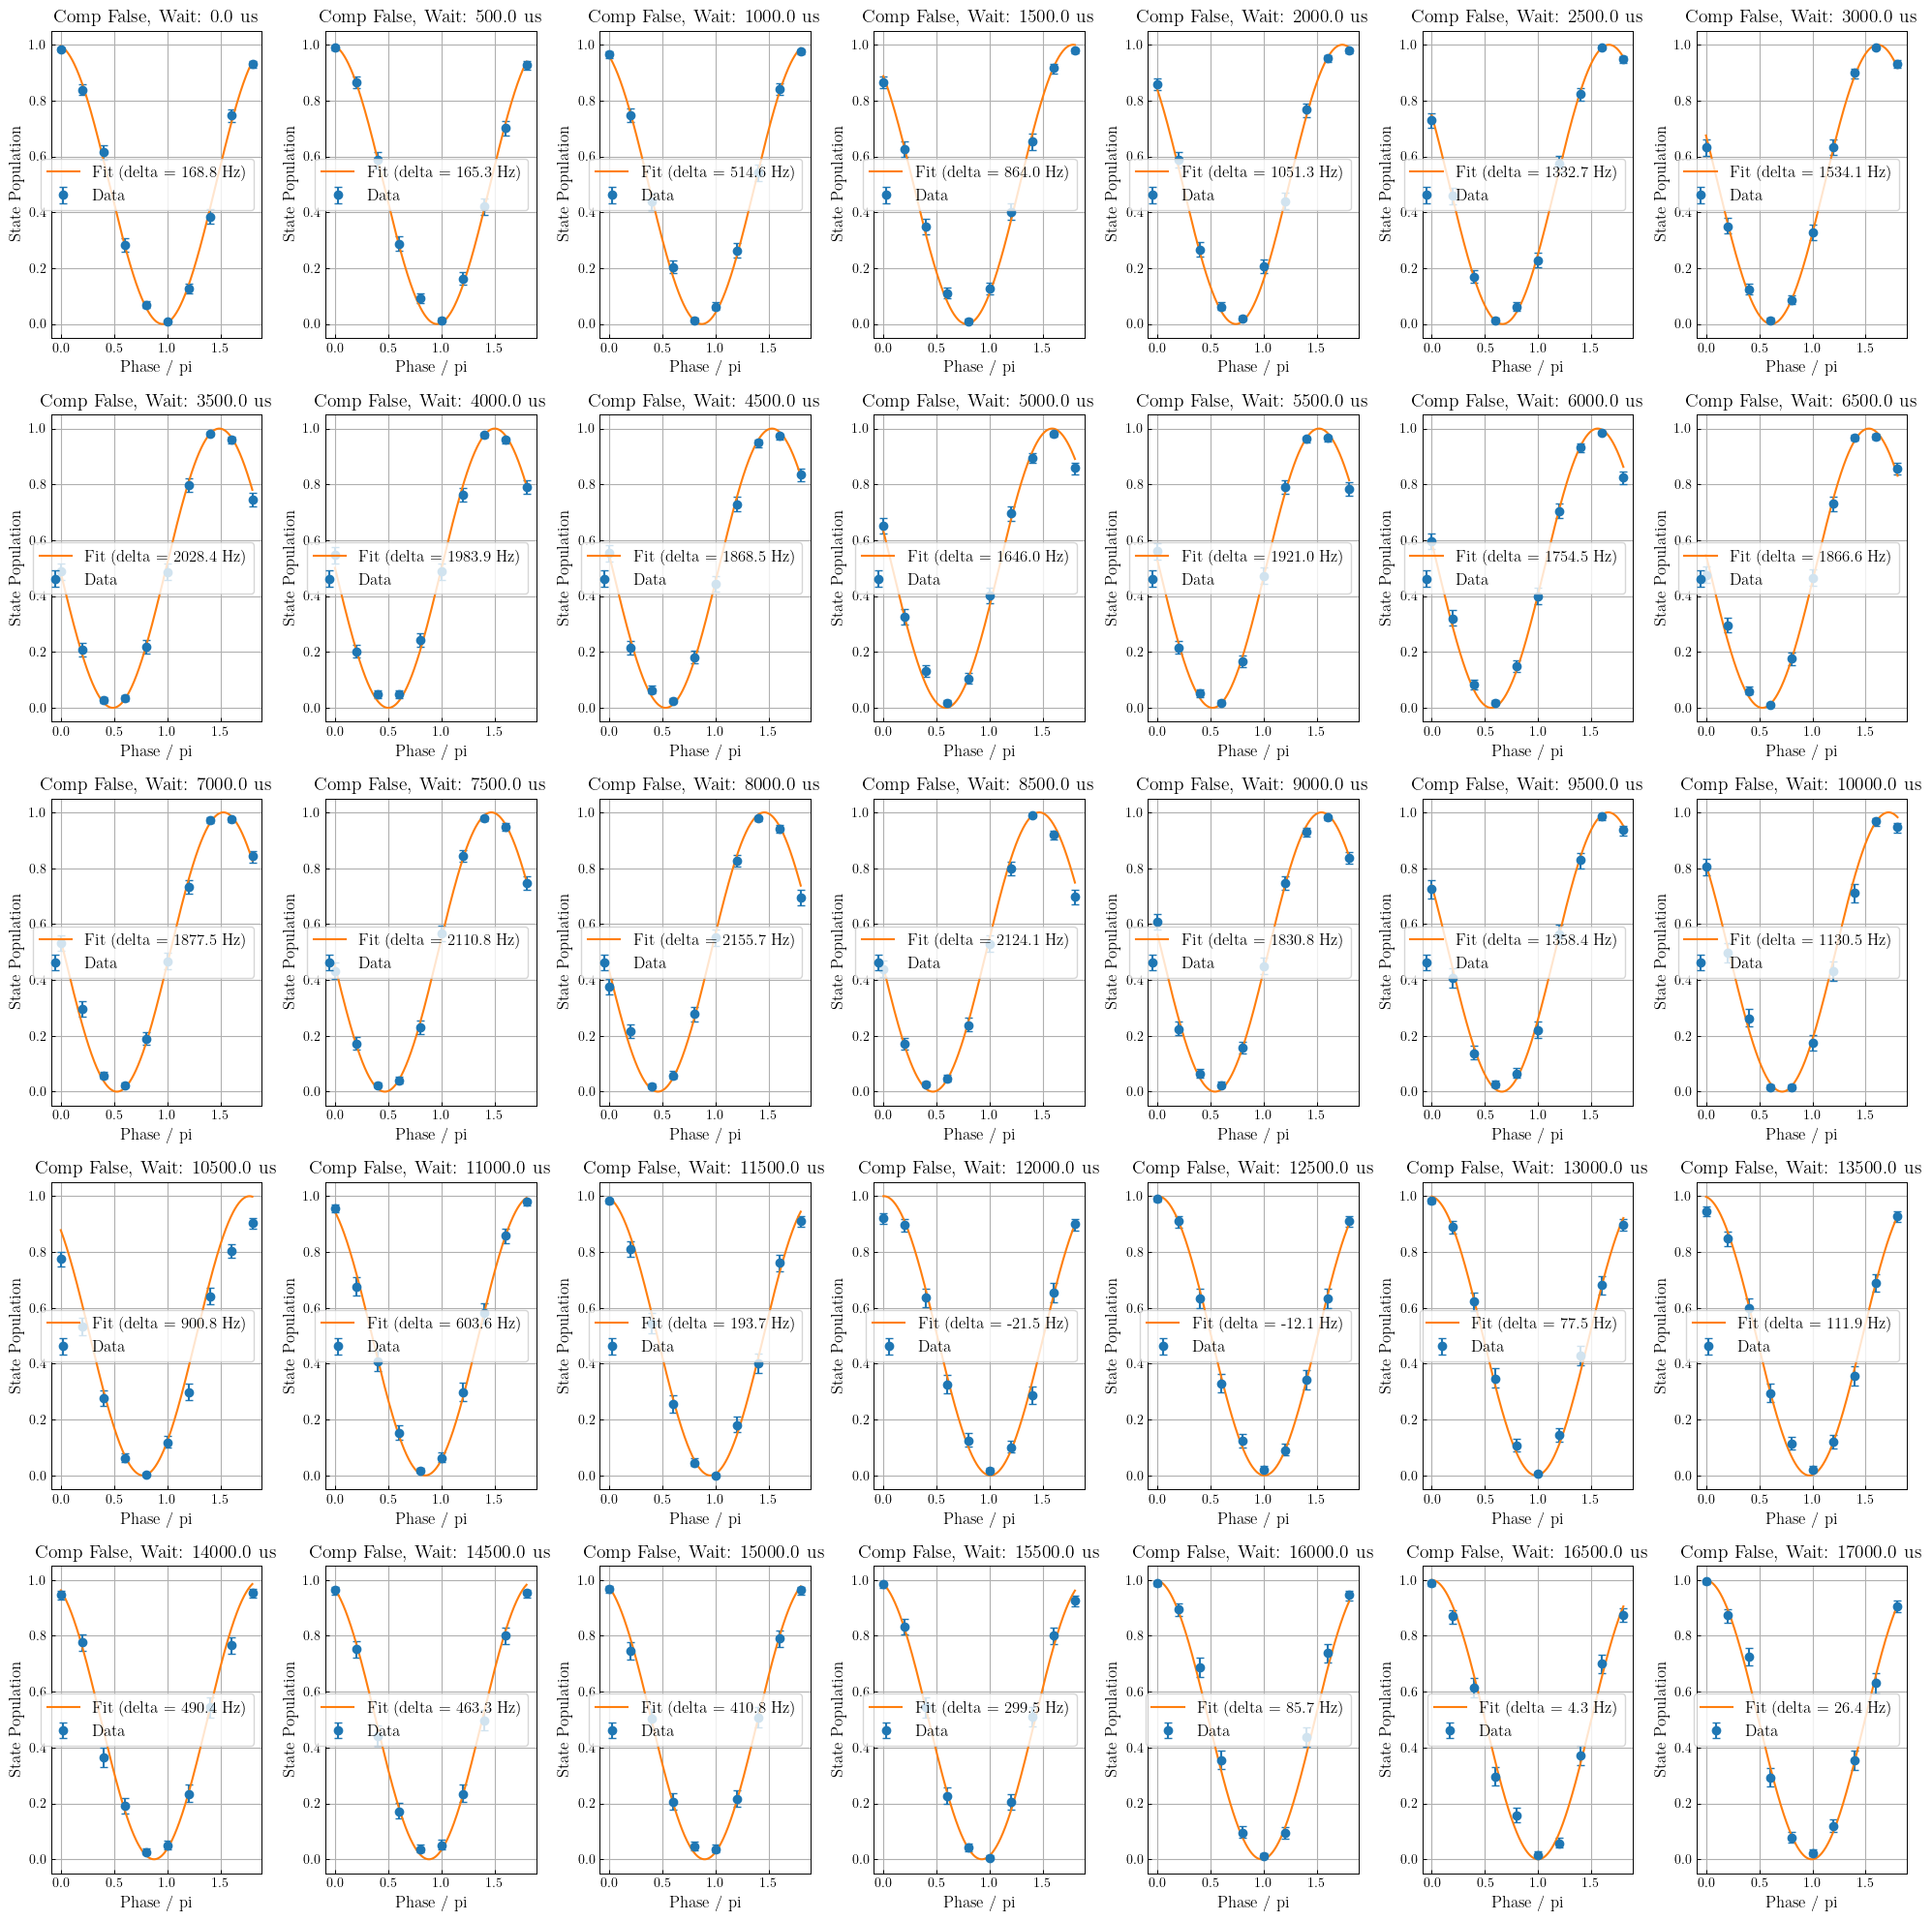


Fitting detuning scans for Comp True


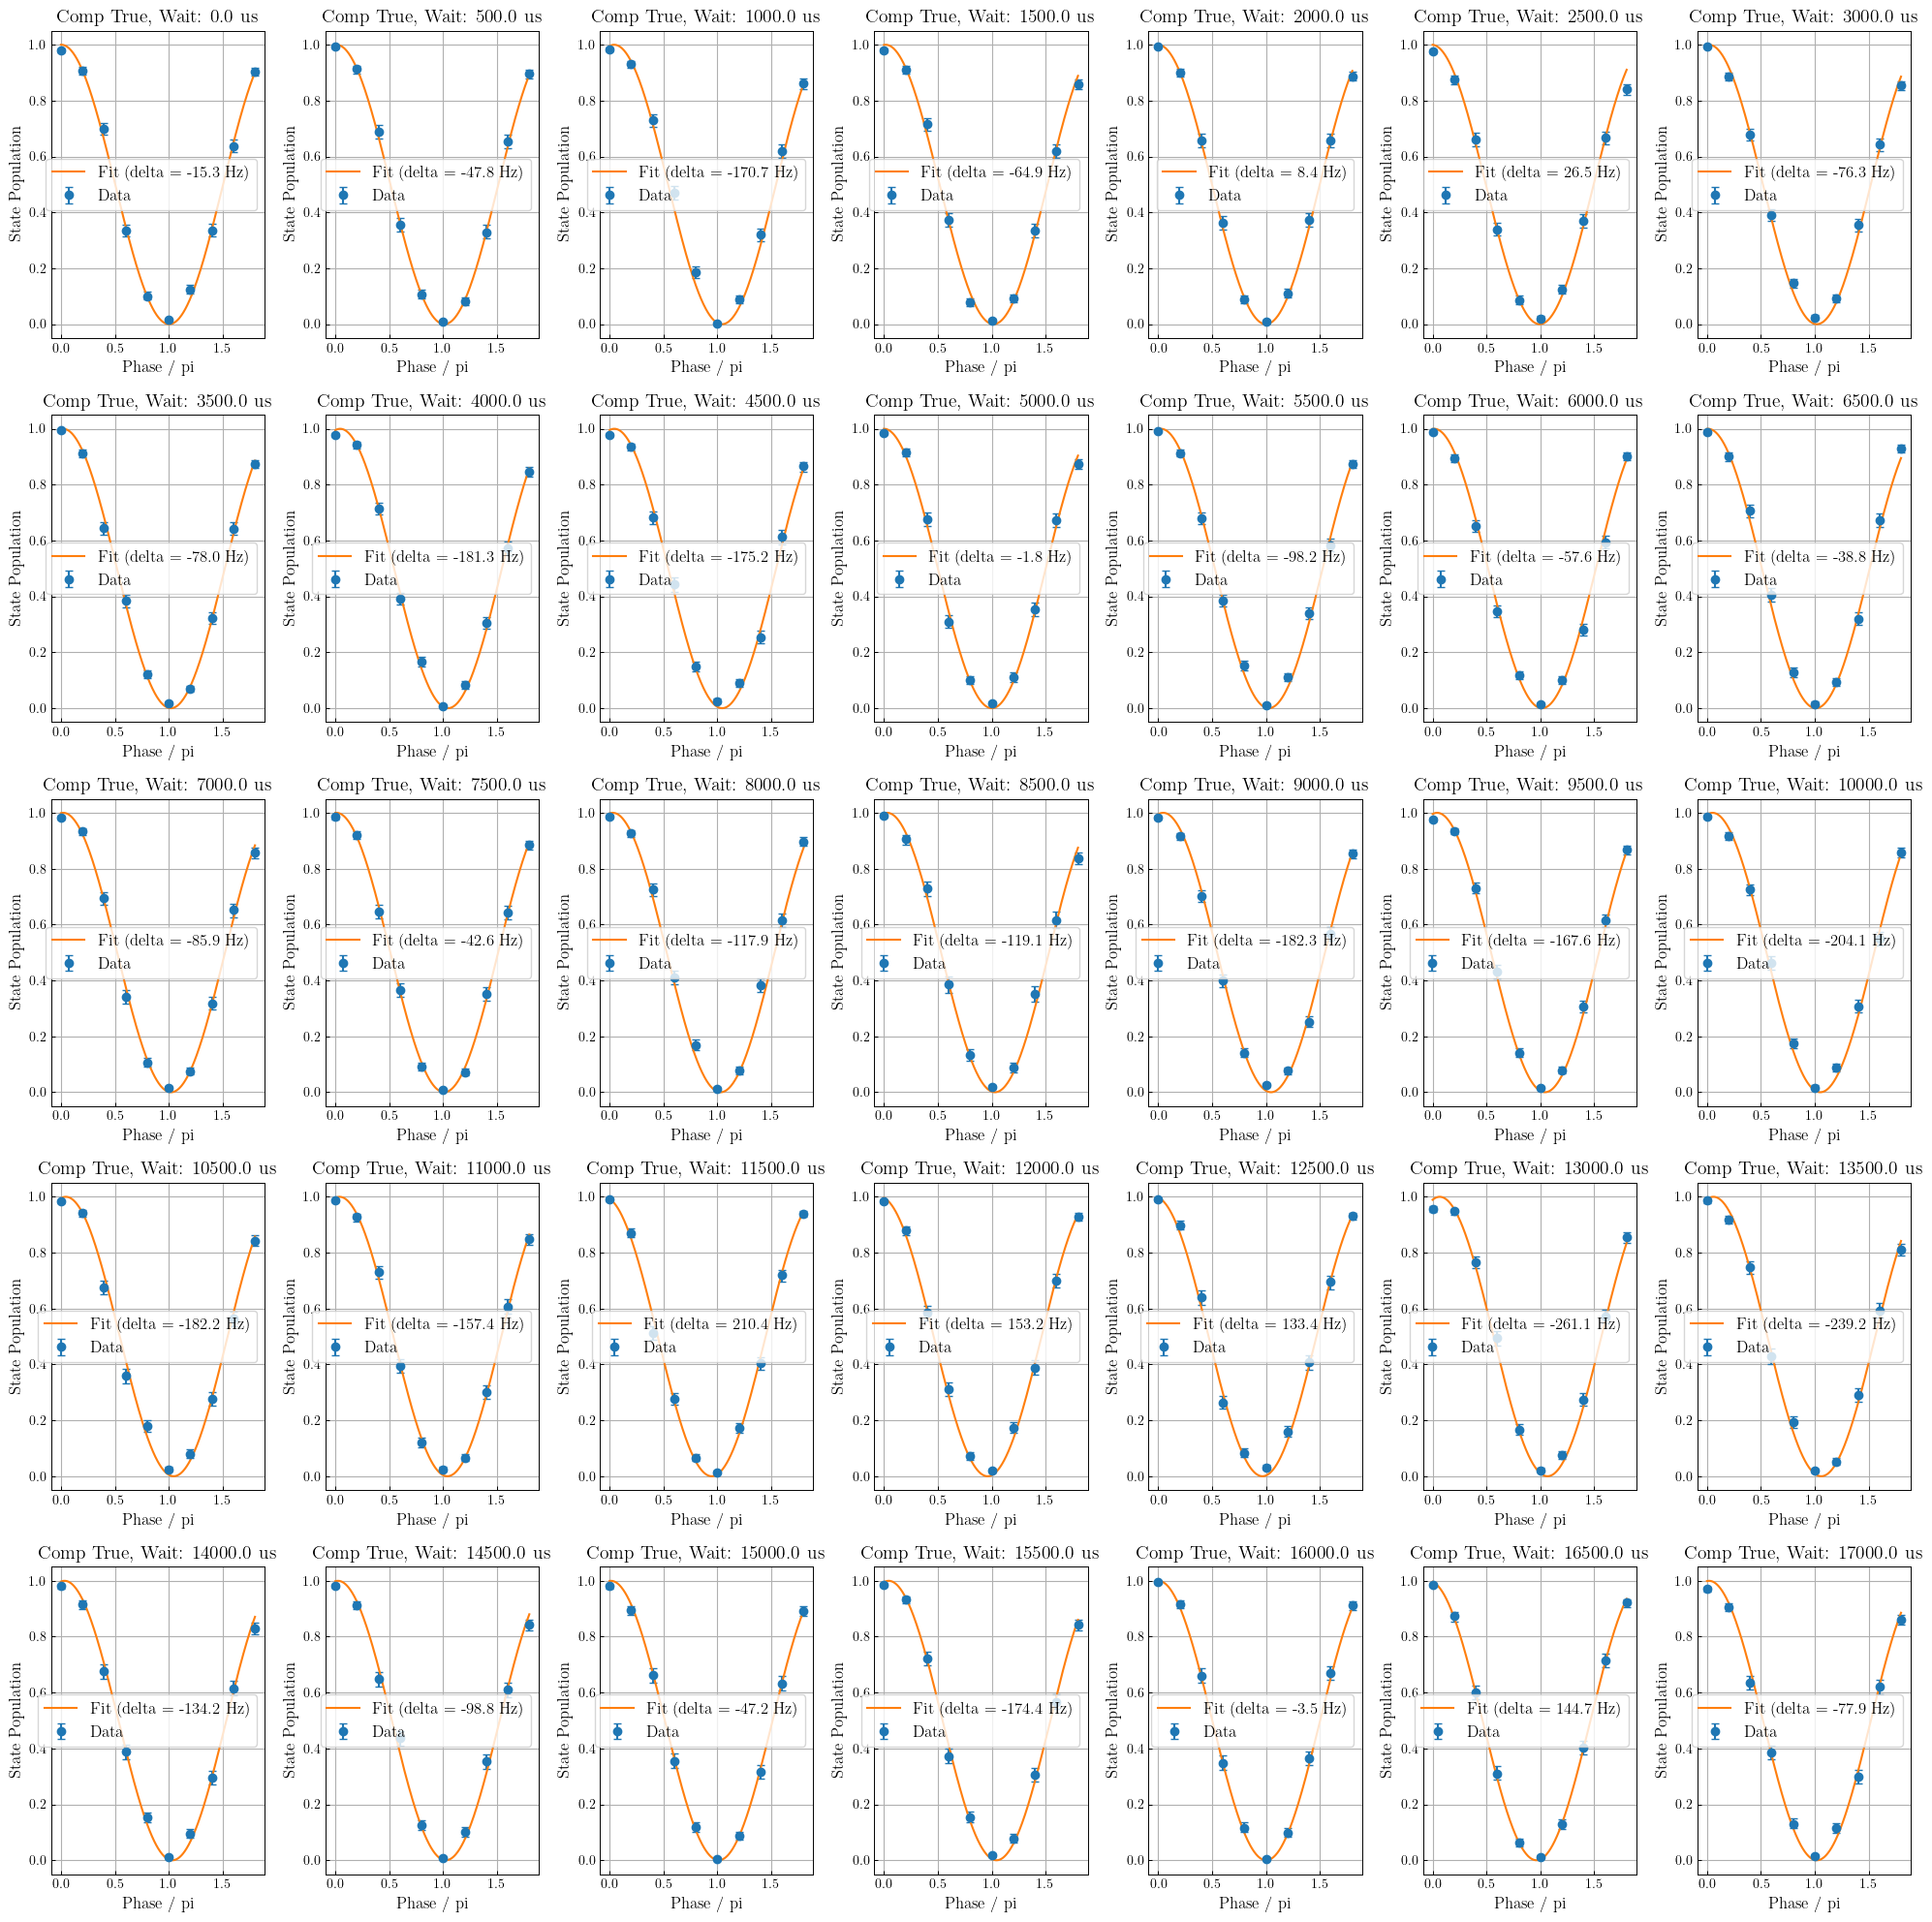


Fitted detunings:

Comp False
  0.0 us: delta = 168.836 Hz +/- 21.958 Hz
  500.0 us: delta = 165.278 Hz +/- 26.256 Hz
  1000.0 us: delta = 514.649 Hz +/- 24.677 Hz
  1500.0 us: delta = 864.001 Hz +/- 26.999 Hz
  2000.0 us: delta = 1051.283 Hz +/- 25.040 Hz
  2500.0 us: delta = 1332.671 Hz +/- 24.304 Hz
  3000.0 us: delta = 1534.113 Hz +/- 25.764 Hz
  3500.0 us: delta = 2028.441 Hz +/- 24.232 Hz
  4000.0 us: delta = 1983.937 Hz +/- 25.292 Hz
  4500.0 us: delta = 1868.509 Hz +/- 25.414 Hz
  5000.0 us: delta = 1645.986 Hz +/- 27.103 Hz
  5500.0 us: delta = 1920.953 Hz +/- 24.506 Hz
  6000.0 us: delta = 1754.520 Hz +/- 26.401 Hz
  6500.0 us: delta = 1866.608 Hz +/- 24.410 Hz
  7000.0 us: delta = 1877.544 Hz +/- 24.521 Hz
  7500.0 us: delta = 2110.786 Hz +/- 24.556 Hz
  8000.0 us: delta = 2155.676 Hz +/- 25.914 Hz
  8500.0 us: delta = 2124.083 Hz +/- 25.193 Hz
  9000.0 us: delta = 1830.786 Hz +/- 25.438 Hz
  9500.0 us: delta = 1358.396 Hz +/- 31.035 Hz
  10000.0 us: delta = 1130.529 Hz +/-

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit


def unitary_product_with_ket_zero(pi_time, T_between_pulses, delta, phase_pi):
    omega = np.pi / (pi_time * 1e-6)
    t_pi_over_2 = (pi_time * 1e-6) / 2

    def U1(omega, t):
        H = np.array([[0, omega / 2], [omega / 2, delta]], dtype=complex)
        return expm(-1j * H * t)

    def U_wait(delta, t):
        H = np.array([[0, 0], [0, delta]], dtype=complex)
        return expm(-1j * H * t)

    def U2(omega, delta, phase_pi, t):
        phase = np.pi * phase_pi
        H = np.array(
            [[0, omega * np.exp(-1j * phase) / 2], [omega * np.exp(1j * phase) / 2, delta]],
            dtype=complex,
        )
        return expm(-1j * H * t)

    product = U2(omega, delta, phase_pi, t_pi_over_2) @ U_wait(delta, T_between_pulses) @ U1(omega, t_pi_over_2)
    ket_zero = np.array([1, 0], dtype=complex)
    result = product @ ket_zero
    state_pop = np.abs(result) ** 2
    return state_pop[1]


def fit_detuning_for_one_dataset(
    ket_data,
    lower_error,
    upper_error,
    phase_list,
    pi_time,
    T_between_pulses,
    initial_delta_guess=2 * np.pi * 100,
):
    ket_data = np.array(ket_data, dtype=float)
    lower_error = np.array(lower_error, dtype=float)
    upper_error = np.array(upper_error, dtype=float)
    phase_array = np.array(phase_list, dtype=float)

    if ket_data.shape[0] != phase_array.shape[0]:
        raise ValueError(f"ket_data has {ket_data.shape[0]} points but phase_list has {phase_array.shape[0]} points")

    valid = np.isfinite(ket_data) & np.isfinite(lower_error) & np.isfinite(upper_error)
    if np.count_nonzero(valid) < 4:
        return None, None

    phases_valid = phase_array[valid]
    ket_data_valid = ket_data[valid]
    lower_error_valid = lower_error[valid]
    upper_error_valid = upper_error[valid]

    sigma = (np.abs(upper_error_valid) + np.abs(lower_error_valid)) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    def ramsey_model(phase_pi, delta):
        return np.array([unitary_product_with_ket_zero(pi_time, T_between_pulses, delta, ph) for ph in phase_pi])

    try:
        params, covariance = curve_fit(
            ramsey_model,
            phases_valid,
            ket_data_valid,
            p0=[initial_delta_guess],
            sigma=sigma,
            absolute_sigma=True,
            maxfev=20000,
        )
        delta_opt = params[0]
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            delta_err = errors[0] if np.isfinite(errors[0]) else None
        else:
            delta_err = None
        return delta_opt, delta_err
    except RuntimeError:
        return None, None


def fit_all_wait_times_to_detuning(
    wait_time_list,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    phase_list,
    pi_time,
    T_between_pulses,
    initial_delta_guess=2 * np.pi * 100,
):
    fit_wait_times_list = []
    fit_detunings_list = []
    fit_detuning_errors_list = []

    for wt_label, kd, le, ue in zip(wait_time_list, ket_data_list, lower_error_list, upper_error_list):
        fit_wait_times_list.append(wt_label)
        try:
            delta_opt, delta_err = fit_detuning_for_one_dataset(
                kd,
                le,
                ue,
                phase_list,
                pi_time,
                T_between_pulses,
                initial_delta_guess,
            )
        except ValueError as exc:
            print(f"Wait time {wt_label} us: detuning fit skipped ({exc})")
            delta_opt, delta_err = None, None

        fit_detunings_list.append(delta_opt)
        fit_detuning_errors_list.append(delta_err)

    return fit_wait_times_list, fit_detunings_list, fit_detuning_errors_list


def plot_detuning_fits_in_lists(
    wait_time_list,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    phase_list,
    fit_detunings_list,
    pi_time,
    T_between_pulses,
    comp_flag,
):
    num_plots = len(wait_time_list)
    if num_plots == 0:
        print(f"Comp {comp_flag}: no detuning scans to plot.")
        return

    num_columns = min(7, num_plots)
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows), squeeze=False)
    axes = axes.flatten()
    phase_array = np.array(phase_list, dtype=float)

    for i, (wt_label, kd, le, ue, delta_opt) in enumerate(
        zip(wait_time_list, ket_data_list, lower_error_list, upper_error_list, fit_detunings_list)
    ):
        kd = np.array(kd, dtype=float)
        le = np.array(le, dtype=float)
        ue = np.array(ue, dtype=float)
        ax = axes[i]

        if kd.shape[0] != phase_array.shape[0]:
            ax.set_title(f"Comp {comp_flag}, {wt_label} us skipped")
            ax.axis("off")
            continue

        valid = np.isfinite(kd) & np.isfinite(le) & np.isfinite(ue)
        phases_valid = phase_array[valid]
        kd_valid = kd[valid]
        le_valid = np.abs(le[valid])
        ue_valid = np.abs(ue[valid])

        ax.errorbar(phases_valid, kd_valid, yerr=[le_valid, ue_valid], fmt="o", label="Data", capsize=3)

        if delta_opt is not None:
            fine_phases = np.linspace(phase_array.min(), phase_array.max(), 400)
            fit_curve = np.array([unitary_product_with_ket_zero(pi_time, T_between_pulses, delta_opt, ph) for ph in fine_phases])
            ax.plot(fine_phases, fit_curve, label=f"Fit (delta = {delta_opt / (2 * np.pi):.1f} Hz)")

        ax.set_title(f"Comp {comp_flag}, Wait: {wt_label} us")
        ax.set_xlabel("Phase / pi")
        ax.set_ylabel("State Population")
        ax.set_ylim(-0.05, 1.05)
        ax.grid()
        ax.legend()

    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.savefig(f"ramsey_detuning_fits_comp_{str(comp_flag).lower()}.png", dpi=300)
    plt.show()


def fit_detuning_for_all_comp_groups(
    processed_data_by_comp,
    phase_list,
    pi_time,
    T_between_pulses,
    initial_delta_guess=2 * np.pi * 100,
    do_plot=True,
):
    detuning_fit_results_by_comp = {}
    for comp_flag in (False, True):
        data = processed_data_by_comp[comp_flag]
        wait_times = data["processed_wait_times"]
        if len(wait_times) == 0:
            detuning_fit_results_by_comp[comp_flag] = {
                "fit_wait_times_list": [],
                "fit_detunings_list": [],
                "fit_detuning_errors_list": [],
            }
            continue

        print(f"\nFitting detuning scans for Comp {comp_flag}")
        fit_wait_times_list, fit_detunings_list, fit_detuning_errors_list = fit_all_wait_times_to_detuning(
            wait_times,
            data["ket_data_list"],
            data["lower_error_list"],
            data["upper_error_list"],
            phase_list,
            pi_time,
            T_between_pulses,
            initial_delta_guess,
        )

        detuning_fit_results_by_comp[comp_flag] = {
            "fit_wait_times_list": fit_wait_times_list,
            "fit_detunings_list": fit_detunings_list,
            "fit_detuning_errors_list": fit_detuning_errors_list,
        }

        if do_plot:
            plot_detuning_fits_in_lists(
                wait_times,
                data["ket_data_list"],
                data["lower_error_list"],
                data["upper_error_list"],
                phase_list,
                fit_detunings_list,
                pi_time,
                T_between_pulses,
                comp_flag,
            )

    return detuning_fit_results_by_comp


# These defaults are copied from the original notebook. Check them before using a new dataset.
pi_time = 40.59  # us
T_between_pulses = 100e-6  # s
phase_list = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8]

detuning_fit_results_by_comp = fit_detuning_for_all_comp_groups(
    processed_data_by_comp,
    phase_list,
    pi_time,
    T_between_pulses,
    do_plot=True,
)

active_detuning_fit = detuning_fit_results_by_comp[active_comp_flag]
fit_wait_times_list = active_detuning_fit["fit_wait_times_list"]
fit_detunings_list = active_detuning_fit["fit_detunings_list"]
fit_detuning_errors_list = active_detuning_fit["fit_detuning_errors_list"]

print("\nFitted detunings:")
for comp_flag in (False, True):
    result = detuning_fit_results_by_comp[comp_flag]
    print(f"\nComp {comp_flag}")
    for wt_label, delta, delta_err in zip(
        result["fit_wait_times_list"],
        result["fit_detunings_list"],
        result["fit_detuning_errors_list"],
    ):
        if delta is None:
            print(f"  {wt_label} us: fit failed or insufficient data")
        elif delta_err is not None:
            print(f"  {wt_label} us: delta = {delta / (2 * np.pi):.3f} Hz +/- {delta_err / (2 * np.pi):.3f} Hz")
        else:
            print(f"  {wt_label} us: delta = {delta / (2 * np.pi):.3f} Hz (no error estimate)")


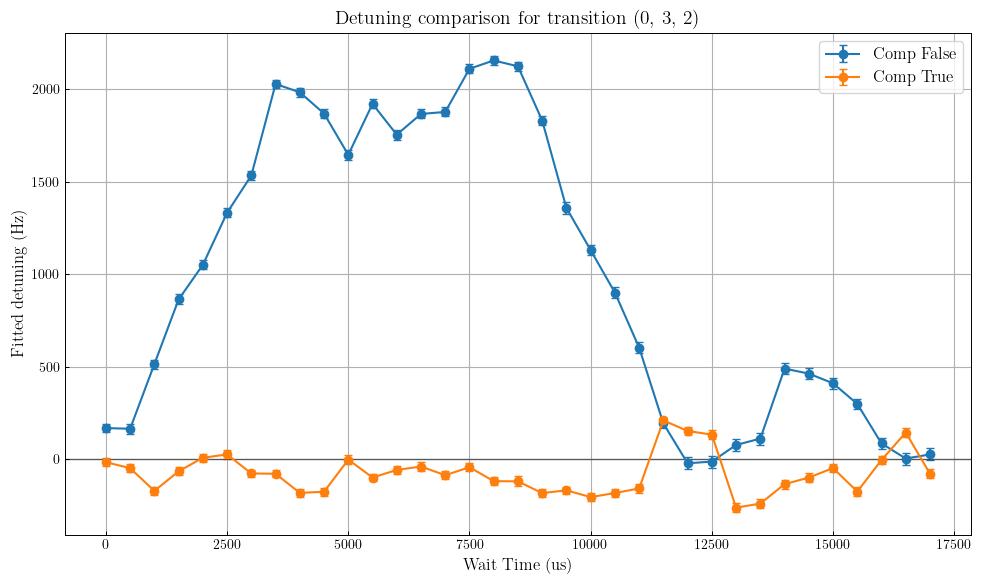

<Axes: title={'center': 'Detuning comparison for transition (0, 3, 2)'}, xlabel='Wait Time (us)', ylabel='Fitted detuning (Hz)'>

In [64]:
import numpy as np
import matplotlib.pyplot as plt


def plot_detuning_comparison_by_comp(detuning_fit_results_by_comp):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {False: "C0", True: "C1"}
    plotted_any = False

    for comp_flag in (False, True):
        result = detuning_fit_results_by_comp.get(comp_flag, {})
        wait_times = np.array(result.get("fit_wait_times_list", []), dtype=float)
        detunings = np.array(
            [np.nan if d is None else d for d in result.get("fit_detunings_list", [])],
            dtype=float,
        )
        detuning_errors = np.array(
            [np.nan if e is None else e for e in result.get("fit_detuning_errors_list", [])],
            dtype=float,
        )

        valid = np.isfinite(wait_times) & np.isfinite(detunings)
        if not np.any(valid):
            print(f"Comp {comp_flag}: no finite detuning points for comparison plot.")
            continue

        wait_times = wait_times[valid]
        detunings_hz = detunings[valid] / (2 * np.pi)
        detuning_errors_hz = detuning_errors[valid] / (2 * np.pi)

        order = np.argsort(wait_times)
        wait_times = wait_times[order]
        detunings_hz = detunings_hz[order]
        detuning_errors_hz = detuning_errors_hz[order]

        yerr = np.where(np.isfinite(detuning_errors_hz), detuning_errors_hz, 0.0)
        ax.errorbar(
            wait_times,
            detunings_hz,
            yerr=yerr,
            fmt="o-",
            capsize=3,
            color=colors[comp_flag],
            ecolor=colors[comp_flag],
            label=f"Comp {comp_flag}",
        )
        plotted_any = True

    if not plotted_any:
        return None

    ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.5)
    ax.set_xlabel("Wait Time (us)")
    ax.set_ylabel("Fitted detuning (Hz)")
    ax.set_title(f"Detuning comparison for transition {target_transition}")
    ax.grid()
    ax.legend()
    plt.tight_layout()
    plt.savefig("detuning_comparison_comp_false_true.png", dpi=300)
    plt.show()
    return ax


plot_detuning_comparison_by_comp(detuning_fit_results_by_comp)


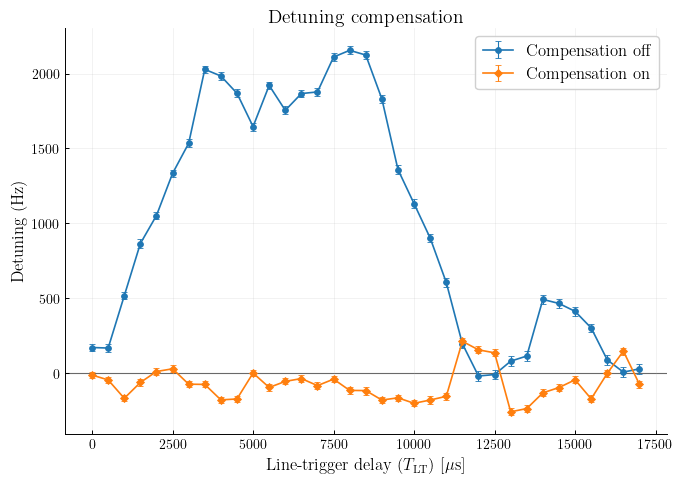

<Axes: title={'center': 'Detuning compensation'}, xlabel='Line-trigger delay ($T_{\\mathrm{LT}}$) [$\\mu$s]', ylabel='Detuning (Hz)'>

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# =========================================================
# NATURE-STYLE PLOT SETTINGS
# =========================================================
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['figure.figsize'] = (8, 8)

rcParams.update({
    # "font.family": "sans-serif",
    # "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    # "text.usetex": False,
    # "mathtext.fontset": "dejavusans",

    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 12,

    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,

    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def plot_detuning_comparison_by_comp(detuning_fit_results_by_comp):
    fig, ax = plt.subplots(figsize=(7, 5))

    colors = {
        False: "C0",
        True: "C1",
    }

    labels = {
        False: "Compensation off",
        True: "Compensation on",
    }

    markers = {
        False: "o",
        True: "D",
    }

    plotted_any = False

    for comp_flag in (False, True):
        result = detuning_fit_results_by_comp.get(comp_flag, {})

        wait_times = np.array(result.get("fit_wait_times_list", []), dtype=float)

        detunings = np.array(
            [np.nan if d is None else d for d in result.get("fit_detunings_list", [])],
            dtype=float,
        )

        detuning_errors = np.array(
            [np.nan if e is None else e for e in result.get("fit_detuning_errors_list", [])],
            dtype=float,
        )

        valid = np.isfinite(wait_times) & np.isfinite(detunings)

        if not np.any(valid):
            print(f"Comp {comp_flag}: no finite detuning points for comparison plot.")
            continue

        wait_times = wait_times[valid]
        detunings_hz = detunings[valid] / (2 * np.pi)
        detuning_errors_hz = detuning_errors[valid] / (2 * np.pi)

        order = np.argsort(wait_times)
        wait_times = wait_times[order]
        detunings_hz = detunings_hz[order]
        detuning_errors_hz = detuning_errors_hz[order]

        yerr = np.where(np.isfinite(detuning_errors_hz), detuning_errors_hz, 0.0)

        ax.errorbar(
            wait_times,
            detunings_hz,
            yerr=yerr,
            fmt=markers[comp_flag],
            markersize=4.2,
            linestyle="-",
            linewidth=1.2,
            capsize=2.5,
            elinewidth=0.8,
            markeredgewidth=0.6,
            color=colors[comp_flag],
            ecolor=colors[comp_flag],
            label=labels[comp_flag],
            zorder=3,
        )

        plotted_any = True

    if not plotted_any:
        return None

    ax.axhline(
        0.0,
        color="0.2",
        linewidth=0.8,
        alpha=0.8,
        zorder=1,
    )

    ax.set_xlabel(r"Line-trigger delay ($T_{\mathrm{LT}}$) [$\mu$s]")
    ax.set_ylabel("Detuning (Hz)")
    ax.set_title("Detuning compensation", pad=4)

    ax.grid(True, which="major", linewidth=0.45, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="best",
        frameon=True,
        framealpha=0.92,
        borderpad=0.45,
        handlelength=1.8,
    )

    fig.tight_layout()

    fig.savefig("detuning_compensation_nature_style.svg", bbox_inches="tight")
    fig.savefig("detuning_compensation_nature_style.pdf", bbox_inches="tight")
    fig.savefig("detuning_compensation_nature_style.png", dpi=600, bbox_inches="tight")

    plt.show()

    return ax


plot_detuning_comparison_by_comp(detuning_fit_results_by_comp)

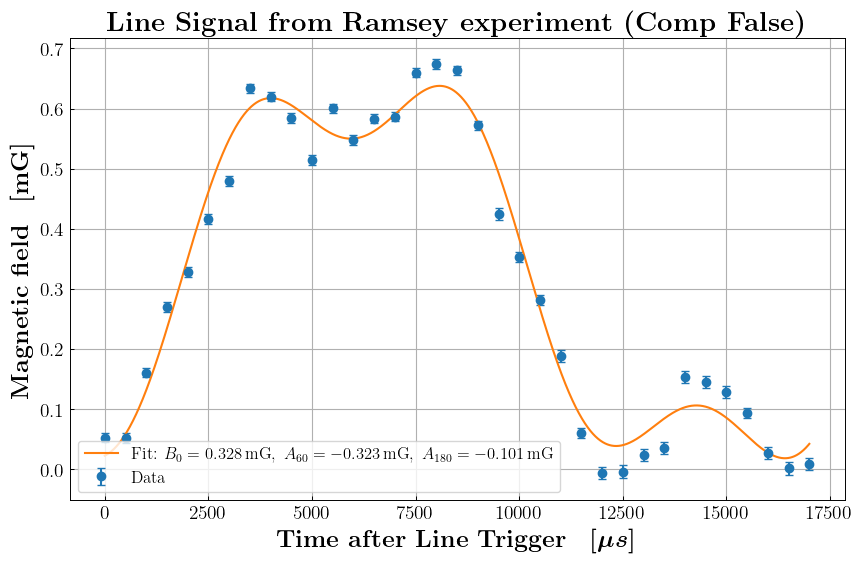

Fitted line-synchronous field (mG):
  B0      = 0.3281 ± 0.0015 mG
  A_60    = -0.3230 ± 0.0021 mG
  phi_60  = 0.8314 ± 0.0063 rad
  A_180   = -0.1006 ± 0.0020 mG
  phi_180 = -0.5112 ± 0.0208 rad


In [66]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

line_signal_comp_flag = False
line_signal_detuning_result = detuning_fit_results_by_comp[line_signal_comp_flag]

fit_wait_times_array = np.array(line_signal_detuning_result["fit_wait_times_list"], dtype=float)
fit_detunings_array = np.array(
    [np.nan if d is None else d for d in line_signal_detuning_result["fit_detunings_list"]],
    dtype=float,
)
fit_detuning_errors_array = np.array(
    [np.nan if e is None else e for e in line_signal_detuning_result["fit_detuning_errors_list"]],
    dtype=float,
)

B_array = (fit_detunings_array / 3.2e3) / (2 * np.pi)
B_err_array = np.abs(fit_detuning_errors_array / 3.2e3 / (2 * np.pi))

mask = np.isfinite(fit_wait_times_array) & np.isfinite(B_array) & np.isfinite(B_err_array)
t_us = fit_wait_times_array[mask]
B = B_array[mask]
B_err = B_err_array[mask]

def line_signal_model(t_us, B0, A60, phi60, A180, phi180):
    t_s = t_us * 1e-6
    return (
        B0
        + A60 * np.cos(2 * np.pi * 60 * t_s + phi60)
        + A180 * np.cos(2 * np.pi * 180 * t_s + phi180)
    )

B0_0 = np.mean(B)
A_guess = 0.5 * (np.max(B) - np.min(B))
p0 = [B0_0, A_guess, 0.0, 0.3 * A_guess, 0.0]

params, covariance = curve_fit(
    line_signal_model,
    t_us,
    B,
    p0=p0,
    sigma=B_err,
    absolute_sigma=True,
    maxfev=20000
)

B0_fit, A60_fit, phi60_fit, A180_fit, phi180_fit = params
if covariance is not None:
    perr = np.sqrt(np.diag(covariance))
else:
    perr = [np.nan] * len(params)
B0_err, A60_err, phi60_err, A180_err, phi180_err = perr

t_fine_us = np.linspace(t_us.min(), t_us.max(), 2000)
B_fit_curve = line_signal_model(t_fine_us, *params)

plt.figure(figsize=(10, 6))
plt.errorbar(
    fit_wait_times_array,
    B_array,
    yerr=B_err_array,
    fmt='o',
    capsize=3,
    label=r'Data'
)
plt.plot(
    t_fine_us,
    B_fit_curve,
    label=(
        r'Fit: $B_0={:.3f}\,\mathrm{{mG}},\ A_{{60}}={:.3f}\,\mathrm{{mG}},\ '
        r'A_{{180}}={:.3f}\,\mathrm{{mG}}$'
    ).format(B0_fit, A60_fit, A180_fit)
)

plt.xlabel(r'\boldmath$\textbf{Time after Line Trigger}\quad [\mu s]$', fontsize=18)
plt.ylabel(r'\boldmath$\textbf{Magnetic field}\quad [\mathrm{mG}]$', fontsize=18)
plt.title(r'\textbf{Line Signal from Ramsey experiment (Comp False)}', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid()
plt.legend(fontsize=12)
plt.savefig('line_signal_fit_60_180Hz_comp_false.png', dpi=300, bbox_inches="tight")
plt.show()

print("Fitted line-synchronous field (mG):")
print("  B0      = {:.4f} ± {:.4f} mG".format(B0_fit, B0_err))
print("  A_60    = {:.4f} ± {:.4f} mG".format(A60_fit, A60_err))
print("  phi_60  = {:.4f} ± {:.4f} rad".format(phi60_fit, phi60_err))
print("  A_180   = {:.4f} ± {:.4f} mG".format(A180_fit, A180_err))
print("  phi_180 = {:.4f} ± {:.4f} rad".format(phi180_fit, phi180_err))


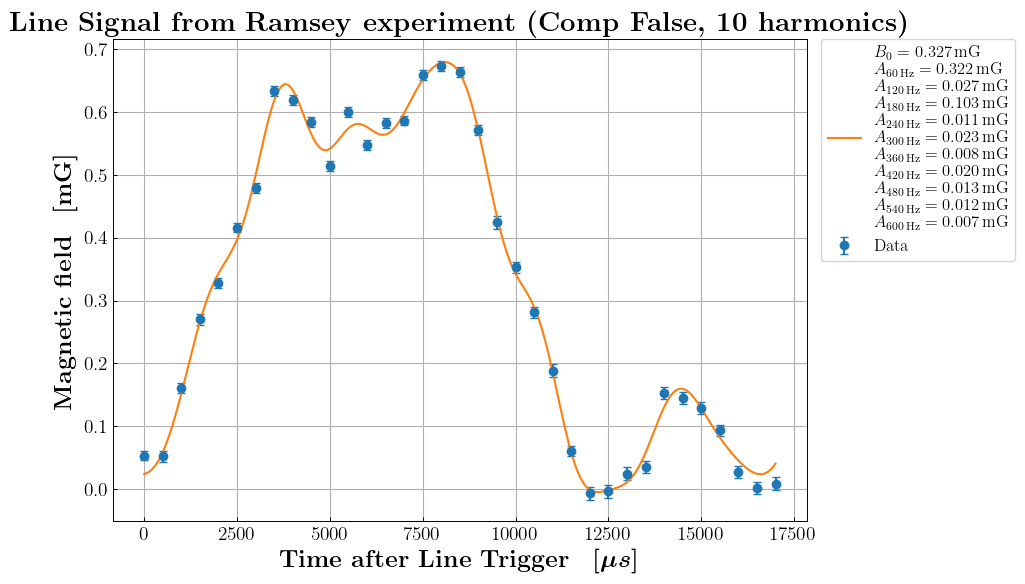

Fitted line-synchronous field (mG):
  B0      = 0.3271 ± 0.0015 mG
  A_ 60   = 0.3218 ± 0.0021 mG
  phi_ 60 = -2.2977 ± 0.0064 rad
  A_120   = 0.0270 ± 0.0021 mG
  phi_120 = 0.6952 ± 0.0786 rad
  A_180   = 0.1027 ± 0.0021 mG
  phi_180 = 2.6030 ± 0.0208 rad
  A_240   = 0.0109 ± 0.0021 mG
  phi_240 = 2.4342 ± 0.1943 rad
  A_300   = 0.0229 ± 0.0021 mG
  phi_300 = -2.0763 ± 0.0899 rad
  A_360   = 0.0081 ± 0.0021 mG
  phi_360 = -0.9218 ± 0.2634 rad
  A_420   = 0.0205 ± 0.0021 mG
  phi_420 = 2.9784 ± 0.1024 rad
  A_480   = 0.0134 ± 0.0021 mG
  phi_480 = 0.8716 ± 0.1550 rad
  A_540   = 0.0116 ± 0.0021 mG
  phi_540 = 0.7755 ± 0.1813 rad
  A_600   = 0.0070 ± 0.0021 mG
  phi_600 = -2.2221 ± 0.2983 rad


: 

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

line_signal_comp_flag = False
line_signal_detuning_result = detuning_fit_results_by_comp[line_signal_comp_flag]

fit_wait_times_array = np.array(line_signal_detuning_result["fit_wait_times_list"], dtype=float)
fit_detunings_array = np.array(
    [np.nan if d is None else d for d in line_signal_detuning_result["fit_detunings_list"]],
    dtype=float,
)
fit_detuning_errors_array = np.array(
    [np.nan if e is None else e for e in line_signal_detuning_result["fit_detuning_errors_list"]],
    dtype=float,
)

B_array = (fit_detunings_array / (3.20153e3)) / (2 * np.pi)
B_err_array = np.abs(fit_detuning_errors_array / 3.20153e3 / (2 * np.pi))

mask = np.isfinite(fit_wait_times_array) & np.isfinite(B_array) & np.isfinite(B_err_array)
t_us = fit_wait_times_array[mask]
B = B_array[mask]
B_err = B_err_array[mask]

fit_freqs = [60, 120, 180, 240, 300, 360, 420, 480, 540, 600]

def line_signal_model(t_us, *params):
    t_s = t_us * 1e-6
    B0 = params[0]
    y = B0
    for i, f in enumerate(fit_freqs):
        A = params[1 + 2 * i]
        phi = params[1 + 2 * i + 1]
        y = y + A * np.cos(2 * np.pi * f * t_s + phi)
    return y

B0_0 = np.mean(B)
A_guess = 0.5 * (np.max(B) - np.min(B))
p0 = [B0_0]
for i, f in enumerate(fit_freqs):
    if i == 0:
        A0 = A_guess
    else:
        A0 = 0.3 * A_guess
    p0.extend([A0, 0.0])

lower_bounds = [-np.inf]
upper_bounds = [np.inf]

for i in range(len(fit_freqs)):
    lower_bounds.extend([0.0, -np.inf])
    upper_bounds.extend([np.inf, np.inf])

params, covariance = curve_fit(
    line_signal_model,
    t_us,
    B,
    p0=p0,
    sigma=B_err,
    absolute_sigma=True,
    maxfev=20000,
    bounds=(lower_bounds, upper_bounds)
)

if covariance is not None:
    perr = np.sqrt(np.diag(covariance))
else:
    perr = [np.nan] * len(params)

B0_fit = params[0]
B0_err = perr[0]

harmonic_results = []
for i, f in enumerate(fit_freqs):
    A = params[1 + 2 * i]
    phi = params[1 + 2 * i + 1]
    A_err = perr[1 + 2 * i]
    phi_err = perr[1 + 2 * i + 1]
    harmonic_results.append((f, A, A_err, phi, phi_err))

t_fine_us = np.linspace(t_us.min(), t_us.max(), 2000)
B_fit_curve = line_signal_model(t_fine_us, *params)

legend_lines = [r'$B_0={:.3f}\,\mathrm{{mG}}$'.format(B0_fit)]
for f, A, A_err, phi, phi_err in harmonic_results:
    legend_lines.append(r'$A_{{{:g}\,\mathrm{{Hz}}}}={:.3f}\,\mathrm{{mG}}$'.format(f, A))
fit_label = '\n'.join(legend_lines)

plt.figure(figsize=(10, 6))
plt.errorbar(
    fit_wait_times_array,
    B_array,
    yerr=B_err_array,
    fmt='o',
    capsize=3,
    label=r'Data'
)
plt.plot(
    t_fine_us,
    B_fit_curve,
    label=fit_label
)

plt.xlabel(r'\boldmath$\textbf{Time after Line Trigger}\quad [\mu s]$', fontsize=18)
plt.ylabel(r'\boldmath$\textbf{Magnetic field}\quad [\mathrm{mG}]$', fontsize=18)
plt.title(r'\textbf{Line Signal from Ramsey experiment (Comp False, 10 harmonics)}', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid()

plt.legend(
    fontsize=12,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0
)

plt.tight_layout()
plt.savefig('line_signal_fit_10_harmonics_comp_false.png', dpi=300, bbox_inches="tight")
plt.show()

print("Fitted line-synchronous field (mG):")
print("  B0      = {:.4f} ± {:.4f} mG".format(B0_fit, B0_err))
for f, A, A_err, phi, phi_err in harmonic_results:
    print("  A_{:3.0f}   = {:.4f} ± {:.4f} mG".format(f, A, A_err))
    print("  phi_{:3.0f} = {:.4f} ± {:.4f} rad".format(f, phi, phi_err))


def save_fit_parameters(filename, B0_fit, B0_err, harmonic_results):
    with open(filename, "w") as f:
        f.write("# B0 B0_err (mG)\n")
        f.write("{:.18e} {:.18e}\n".format(B0_fit, B0_err))
        f.write("# f_Hz A A_err phi phi_err\n")
        for f_hz, A, A_err, phi, phi_err in harmonic_results:
            f.write(
                "{:10.3f} {:.18e} {:.18e} {:.18e} {:.18e}\n".format(
                    f_hz, A, A_err, phi, phi_err
                )
            )

save_fit_parameters("line_signal_fit_params_comp_false_10harmonics.txt", B0_fit, B0_err, harmonic_results)


In [ ]:
# import numpy as np

# def compute_detuning_from_line_fit(
#     pulse_train,
#     fractions,
#     pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
#     B0=0.2289,
#     A60=-0.2791,
#     phi60=1.0002,
#     A180=-0.0774,
#     phi180=-0.2650
# ):
#     def B_line_mG(t, B0=B0, A60=A60, phi60=phi60, A180=A180, phi180=phi180):
#         return B0 + A60 * np.cos(2 * np.pi * 60 * t + phi60) + A180 * np.cos(2 * np.pi * 180 * t + phi180)

#     def B_rel_G(t):
#         return (B_line_mG(t) - B_line_mG(0.0)) * 1e-3

#     def compute_pi_times(pi_t):
#         transition_strengths = np.loadtxt(
#             'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p216.txt',
#             delimiter=','
#         )
#         transition_strengths[transition_strengths == 0] = np.nan
#         strengths = np.array([
#             transition_strengths[22, 1],
#             transition_strengths[14, 0],
#             transition_strengths[5, 2],
#             transition_strengths[16, 4],
#             transition_strengths[15, 4]
#         ])
#         factors = np.array(pi_t) * strengths
#         Fs = [1, 2, 3, 4]
#         row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
#         col_labels = [-2, -1, 0, 1, 2]
#         pi_times = np.zeros((24, 5))
#         for i in range(np.shape(transition_strengths)[0]):
#             for j in range(np.shape(transition_strengths)[1]):
#                 if not np.isnan(transition_strengths[i, j]):
#                     delta_m = (row_labels[i][1] - col_labels[j]) + 2
#                     pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
#         return pi_times

#     def get_pi_times(transitions, matrix):
#         Fs = [1, 2, 3, 4]
#         states = []
#         for i in Fs:
#             for j in range(2 * i + 1):
#                 mF = i - j
#                 states.append([i, mF])
#         row_labels = states
#         col_labels = [-2, -1, 0, 1, 2]
#         pi_times_list = []
#         for transition in transitions:
#             row_label = [transition[1], transition[2]]
#             col_label = transition[0]
#             row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
#             col_index = col_labels.index(col_label) if col_label in col_labels else None
#             if row_index is not None and col_index is not None:
#                 pi_times_list.append(matrix[row_index, col_index])
#             else:
#                 pi_times_list.append(np.nan)
#         return pi_times_list

#     def get_pulse_schedule(rabi_freqs, fractions):
#         if len(rabi_freqs) != len(fractions):
#             raise ValueError(f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length.")
#         times = []
#         t_current = 0.0
#         for Omega, frac in zip(rabi_freqs, fractions):
#             if not 0 <= frac <= 1:
#                 raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
#             theta = 2.0 * np.arcsin(np.sqrt(frac))
#             t_pulse = theta / Omega if Omega > 0 else 0.0
#             t_start = t_current
#             t_end = t_current + t_pulse
#             times.append((t_start, t_end))
#             t_current = t_end
#         return times

#     pi_times_matrix = compute_pi_times(pi_t)
#     pi_times_train = get_pi_times(pulse_train, pi_times_matrix)
#     for i, tr in enumerate(pulse_train):
#         if tr[0] == 0 and tr[1] == 0 and tr[2] == 0:
#             pi_times_train[i] = 1e6
#     rabi_frequencies_list = np.pi / np.array(pi_times_train)

#     sens_matrix = np.loadtxt(
#         'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\sensitivities_4p216.txt',
#         delimiter=','
#     )
#     sens_list = get_pi_times(pulse_train, sens_matrix)
#     for i, tr in enumerate(pulse_train):
#         if tr[0] == 0 and tr[1] == 0 and tr[2] == 0:
#             sens_list[i] = 0.0
#     sens_array = np.array(sens_list)
#     print(sens_array)
#     schedule = get_pulse_schedule(rabi_frequencies_list, fractions)
#     pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule]
#     print(pulses_sec)
#     detuning_values_MHz = []
#     for i, (start_s, _) in enumerate(pulses_sec):
#         B_here_G = B_rel_G(start_s)
#         det_here_MHz = B_here_G * sens_array[i]
#         detuning_values_MHz.append(det_here_MHz)

#     detuning_values_MHz = np.array(detuning_values_MHz, dtype=float)
#     return detuning_values_MHz

import numpy as np

def load_line_fit_parameters(filename):
    B0_line = np.loadtxt(filename, comments='#', max_rows=1)
    B0_fit, B0_err = B0_line
    harmonics = np.loadtxt(filename, comments='#', skiprows=2)
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A = harmonics[:, 1]
    A_err = harmonics[:, 2]
    phi = harmonics[:, 3]
    phi_err = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A, A_err, phi, phi_err

def compute_detuning_from_line_fit(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="line_signal_fit_params.txt"
):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        # print(B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs)
        def B_line_mG(t):
            t = np.asarray(t)
            y = B0_fit
            for f, A, phi in zip(freqs, A_vals, phi_vals):
                y = y + A * np.cos(2 * np.pi * f * t + phi)
            return y
    else:
        def B_line_mG(t, B0=B0, A60=A60, phi60=phi60, A180=A180, phi180=phi180):
            return B0 + A60 * np.cos(2 * np.pi * 60 * t + phi60) + A180 * np.cos(2 * np.pi * 180 * t + phi180)

    def B_rel_G(t):
        return (B_line_mG(t) - B_line_mG(0.0)) * 1e-3

    def compute_pi_times(pi_t):
        transition_strengths = np.loadtxt(
            'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p216.txt',
            delimiter=','
        )
        transition_strengths[transition_strengths == 0] = np.nan
        strengths = np.array([
            transition_strengths[22, 1],
            transition_strengths[14, 0],
            transition_strengths[5, 2],
            transition_strengths[16, 4],
            transition_strengths[15, 4]
        ])
        factors = np.array(pi_t) * strengths
        Fs = [1, 2, 3, 4]
        row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
        col_labels = [-2, -1, 0, 1, 2]
        pi_times = np.zeros((24, 5))
        for i in range(np.shape(transition_strengths)[0]):
            for j in range(np.shape(transition_strengths)[1]):
                if not np.isnan(transition_strengths[i, j]):
                    delta_m = (row_labels[i][1] - col_labels[j]) + 2
                    pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
        return pi_times

    def get_pi_times(transitions, matrix):
        Fs = [1, 2, 3, 4]
        states = []
        for i in Fs:
            for j in range(2 * i + 1):
                mF = i - j
                states.append([i, mF])
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]
        pi_times_list = []
        for transition in transitions:
            row_label = [transition[1], transition[2]]
            col_label = transition[0]
            row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
            col_index = col_labels.index(col_label) if col_label in col_labels else None
            if row_index is not None and col_index is not None:
                pi_times_list.append(matrix[row_index, col_index])
            else:
                pi_times_list.append(np.nan)
        return pi_times_list

    def get_pulse_schedule(rabi_freqs, fractions):
        if len(rabi_freqs) != len(fractions):
            raise ValueError(f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length.")
        times = []
        t_current = 0.0
        for Omega, frac in zip(rabi_freqs, fractions):
            if not 0 <= frac <= 1:
                raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
            theta = 2.0 * np.arcsin(np.sqrt(frac))
            t_pulse = theta / Omega if Omega > 0 else 0.0
            t_start = t_current
            t_end = t_current + t_pulse
            times.append((t_start, t_end))
            t_current = t_end
        return times

    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times(pulse_train, pi_times_matrix)
    for i, tr in enumerate(pulse_train):
        if tr[0] == 0 and tr[1] == 0 and tr[2] == 0:
            pi_times_train[i] = 1e6
    rabi_frequencies_list = np.pi / np.array(pi_times_train)

    sens_matrix = np.loadtxt(
        'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\sensitivities_4p216.txt',
        delimiter=','
    )
    sens_list = get_pi_times(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr[0] == 0 and tr[1] == 0 and tr[2] == 0:
            sens_list[i] = 0.0
    sens_array = np.array(sens_list)
    print(sens_array)
    schedule = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule]
    print(pulses_sec)
    detuning_values_MHz = []
    for i, (start_s, _) in enumerate(pulses_sec):
        B_here_G = B_rel_G(start_s)
        det_here_MHz = B_here_G * sens_array[i]
        detuning_values_MHz.append(det_here_MHz)

    detuning_values_MHz = np.array(detuning_values_MHz, dtype=float)
    return detuning_values_MHz


In [ ]:
pulse_train = [[0,0,0], [-1,4,-3], [0,0,0], [-1,4,-3]]
fractions = [(np.sin((4000/1e6)*(np.pi/2)))**2, 0.5, (np.sin((100/1e6)*(np.pi/2)))**2, 0.5]

detuning_values = compute_detuning_from_line_fit(pulse_train, fractions)
print(detuning_values)

In [ ]:
import numpy as np

def compute_detuning_and_phase_feedforward(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    return_mod_2pi=True,
):
    # --- your B-field model (mG) ---
    def B_line_mG(t):
        return (B0
                + A60 * np.cos(2*np.pi*60*t + phi60)
                + A180 * np.cos(2*np.pi*180*t + phi180))

    def B_rel_G(t):
        return (B_line_mG(t) - B_line_mG(0.0)) * 1e-3  # mG -> G

    # --- analytic integral of B_rel_G from 0 to t (units: G*s) ---
    def int_B_rel_G(t):
        # Integral of cos(2π f t + φ) dt = (1/(2π f)) [sin(2π f t + φ) - sin(φ)]
        term60  = A60  * (np.sin(2*np.pi*60*t  + phi60)  - np.sin(phi60))  / (2*np.pi*60)
        term180 = A180 * (np.sin(2*np.pi*180*t + phi180) - np.sin(phi180)) / (2*np.pi*180)
        # B0 cancels in B_rel, so it should NOT appear here
        return (term60 + term180) * 1e-3  # mG*s -> G*s

    # --- your pi-time / rabi / schedule machinery (unchanged logic) ---
    def compute_pi_times(pi_t):
        transition_strengths = np.loadtxt(
            'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p216.txt',
            delimiter=','
        )
        transition_strengths[transition_strengths == 0] = np.nan
        strengths = np.array([
            transition_strengths[22, 1],
            transition_strengths[14, 0],
            transition_strengths[5, 2],
            transition_strengths[16, 4],
            transition_strengths[15, 4]
        ])
        factors = np.array(pi_t) * strengths
        Fs = [1, 2, 3, 4]
        row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
        col_labels = [-2, -1, 0, 1, 2]
        pi_times = np.zeros((24, 5))
        for i in range(np.shape(transition_strengths)[0]):
            for j in range(np.shape(transition_strengths)[1]):
                if not np.isnan(transition_strengths[i, j]):
                    delta_m = (row_labels[i][1] - col_labels[j]) + 2
                    pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
        return pi_times

    def get_pi_times(transitions, matrix):
        Fs = [1, 2, 3, 4]
        states = []
        for i in Fs:
            for j in range(2 * i + 1):
                mF = i - j
                states.append([i, mF])
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]
        out = []
        for transition in transitions:
            row_label = [transition[1], transition[2]]
            col_label = transition[0]
            row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
            col_index = col_labels.index(col_label) if col_label in col_labels else None
            out.append(matrix[row_index, col_index] if (row_index is not None and col_index is not None) else np.nan)
        return out

    def get_pulse_schedule(rabi_freqs, fractions):
        if len(rabi_freqs) != len(fractions):
            raise ValueError("rabi_freqs and fractions must have the same length.")
        times = []
        t_current = 0.0
        for Omega, frac in zip(rabi_freqs, fractions):
            theta = 2.0 * np.arcsin(np.sqrt(frac))
            t_pulse = theta / Omega if Omega > 0 else 0.0
            t_start = t_current
            t_end = t_current + t_pulse
            times.append((t_start, t_end))
            t_current = t_end
        return times

    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times(pulse_train, pi_times_matrix)
    for i, tr in enumerate(pulse_train):
        if tr[0] == 0 and tr[1] == 0 and tr[2] == 0:
            pi_times_train[i] = 1e6  # dummy
    rabi_freqs = np.pi / np.array(pi_times_train)

    sens_matrix = np.loadtxt(
        'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\sensitivities_4p216.txt',
        delimiter=','
    )
    sens_list = get_pi_times(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr[0] == 0 and tr[1] == 0 and tr[2] == 0:
            sens_list[i] = 0.0
    sens = np.array(sens_list, dtype=float)

    schedule_us = get_pulse_schedule(rabi_freqs, fractions)
    schedule_s = [(s*1e-6, e*1e-6) for (s, e) in schedule_us]

    # --- outputs ---
    detuning_at_start_MHz = []
    phase_ff_rad = []

    for i, (t_start, _) in enumerate(schedule_s):
        # detuning (MHz) at pulse start (what you already do)
        det_MHz = B_rel_G(t_start) * sens[i]
        detuning_at_start_MHz.append(det_MHz)

        # phase feedforward: Phi_i = 2π * 1e6 * ∫0^{t_start} det_MHz(t) dt
        # det_MHz(t) = sens[i] * B_rel_G(t)
        int_det_MHz_s = sens[i] * int_B_rel_G(t_start)  # (MHz/G) * (G*s) = MHz*s
        Phi = 2*np.pi * 1e6 * int_det_MHz_s            # rad
        if return_mod_2pi:
            Phi = np.mod(Phi, 2*np.pi)
        phase_ff_rad.append(Phi)

    return np.array(detuning_at_start_MHz), np.array(phase_ff_rad), schedule_s, sens


In [ ]:
pulse_train = [[0,0,0], [-1,4,-3], [0,0,0], [-1,4,-3]]
fractions = [(np.sin((4000/1e6)*(np.pi/2)))**2, 0.5, (np.sin((100/1e6)*(np.pi/2)))**2, 0.5]

detuning_values = compute_detuning_and_phase_feedforward(pulse_train, fractions)
print(detuning_values)

In [ ]:
import numpy as np

def compute_pi_times(pi_t):
    transition_strengths = np.loadtxt(
        'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p216.txt',
        delimiter=','
    )
    transition_strengths[transition_strengths == 0] = np.nan
    strengths = np.array([
        transition_strengths[22, 1],
        transition_strengths[14, 0],
        transition_strengths[5, 2],
        transition_strengths[16, 4],
        transition_strengths[15, 4]
    ])
    factors = np.array(pi_t) * strengths
    Fs = [1, 2, 3, 4]
    row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]
    pi_times = np.zeros((24, 5))
    for i in range(np.shape(transition_strengths)[0]):
        for j in range(np.shape(transition_strengths)[1]):
            if not np.isnan(transition_strengths[i, j]):
                delta_m = (row_labels[i][1] - col_labels[j]) + 2
                pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
    return pi_times

def get_pi_times_from_matrix(transitions, matrix):
    Fs = [1, 2, 3, 4]
    states = []
    for i in Fs:
        for j in range(2 * i + 1):
            mF = i - j
            states.append([i, mF])
    row_labels = states
    col_labels = [-2, -1, 0, 1, 2]
    pi_times_list = []
    for transition in transitions:
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            pi_times_list.append(matrix[row_index, col_index])
        else:
            pi_times_list.append(np.nan)
    return pi_times_list

def get_pulse_schedule(rabi_freqs, fractions):
    if len(rabi_freqs) != len(fractions):
        raise ValueError(f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length.")
    times = []
    t_current = 0.0
    for Omega, frac in zip(rabi_freqs, fractions):
        if not 0 <= frac <= 1:
            raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
        theta = 2.0 * np.arcsin(np.sqrt(frac))
        t_pulse = theta / Omega if Omega > 0 else 0.0
        t_start = t_current
        t_end = t_current + t_pulse
        times.append((t_start, t_end))
        t_current = t_end
    return times

def build_transition_schedules(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168]
):
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)
    for i, tr in enumerate(pulse_train):
        if tr[0] == 0 and tr[1] == 0 and tr[2] == 0:
            pi_times_train[i] = 1e6
    rabi_frequencies_list = np.pi / np.array(pi_times_train)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]
    transition_schedules = {}
    for tr, (t_start, t_end) in zip(pulse_train, pulses_sec):
        key = tuple(tr)
        if key not in transition_schedules:
            transition_schedules[key] = []
        transition_schedules[key].append((t_start, t_end))
    return transition_schedules


In [ ]:
pulse_train = [[-1,4,-3], [0,0,0], [-1,4,-3], [0,0,0], [-1,4,-3]]
fractions = [0.5,(np.sin((100/1e6)*(np.pi/2)))**2, 1, (np.sin((100/1e6)*(np.pi/2)))**2, 0.5]

trans_sched = build_transition_schedules(pulse_train, fractions)
print(trans_sched)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def B_line_mG(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650):
    return B0 + A60 * np.cos(2 * np.pi * 60 * t + phi60) + A180 * np.cos(2 * np.pi * 180 * t + phi180)

def B_rel_G(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650):
    return (B_line_mG(t, B0, A60, phi60, A180, phi180) - B_line_mG(0.0, B0, A60, phi60, A180, phi180)) * 1e-3

def compute_pi_times(pi_t):
    transition_strengths = np.loadtxt(
        'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p216.txt',
        delimiter=','
    )
    transition_strengths[transition_strengths == 0] = np.nan
    strengths = np.array([
        transition_strengths[22, 1],
        transition_strengths[14, 0],
        transition_strengths[5, 2],
        transition_strengths[16, 4],
        transition_strengths[15, 4]
    ])
    factors = np.array(pi_t) * strengths
    Fs = [1, 2, 3, 4]
    row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]
    pi_times = np.zeros((24, 5))
    for i in range(np.shape(transition_strengths)[0]):
        for j in range(np.shape(transition_strengths)[1]):
            if not np.isnan(transition_strengths[i, j]):
                delta_m = (row_labels[i][1] - col_labels[j]) + 2
                pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
    return pi_times

def get_pi_times_from_matrix(transitions, matrix):
    Fs = [1, 2, 3, 4]
    states = []
    for i in Fs:
        for j in range(2 * i + 1):
            mF = i - j
            states.append([i, mF])
    row_labels = states
    col_labels = [-2, -1, 0, 1, 2]
    pi_times_list = []
    for transition in transitions:
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            pi_times_list.append(matrix[row_index, col_index])
        else:
            pi_times_list.append(np.nan)
    return pi_times_list

def get_pulse_schedule(rabi_freqs, fractions):
    if len(rabi_freqs) != len(fractions):
        raise ValueError(f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length.")
    times = []
    t_current = 0.0
    for Omega, frac in zip(rabi_freqs, fractions):
        if not 0 <= frac <= 1:
            raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
        theta = 2.0 * np.arcsin(np.sqrt(frac))
        t_pulse = theta / Omega if Omega > 0 else 0.0
        t_start = t_current
        t_end = t_current + t_pulse
        times.append((t_start, t_end))
        t_current = t_end
    return times

def build_transition_schedules(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168]
):
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)
    for i, tr in enumerate(pulse_train):
        if tr[0] == 0 and tr[1] == 0 and tr[2] == 0:
            pi_times_train[i] = 1e6
    rabi_frequencies_list = np.pi / np.array(pi_times_train)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]
    transition_schedules = {}
    for tr, (t_start, t_end) in zip(pulse_train, pulses_sec):
        key = tuple(tr)
        if key not in transition_schedules:
            transition_schedules[key] = []
        transition_schedules[key].append((t_start, t_end))
    return transition_schedules

import numpy as np
import matplotlib.pyplot as plt

def plot_line_with_transition_shading(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650
):
    transition_schedules = build_transition_schedules(pulse_train, fractions, pi_t=pi_t)
    all_ends = [t_end for intervals in transition_schedules.values() for (_, t_end) in intervals]
    if len(all_ends) == 0:
        return

    t_max = max(all_ends) * 1.05
    t_plot = np.linspace(0.0, t_max, 4000)
    B_plot = B_rel_G(t_plot, B0, A60, phi60, A180, phi180)

    fig, ax = plt.subplots()
    ax.plot(t_plot * 1e6, B_plot, linewidth=1.5, label="B_rel(t)", marker='.', color='red')

    prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for idx, (tr, intervals) in enumerate(transition_schedules.items()):
        color = prop_cycle[idx % len(prop_cycle)]
        for (t_start, t_end) in intervals:
            ax.axvspan(t_start * 1e6, t_end * 1e6, alpha=0.3, color='red')
        ax.plot([], [], color='red', label=str(tr))

    ax.set_xlabel("time (µs)")
    ax.set_ylabel("B_rel (G)")
    ax.set_title("Fitted line signal with active transitions shaded")
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()

    return transition_schedules

import numpy as np
import matplotlib.pyplot as plt

def plot_line_with_transition_shading(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650
):
    transition_schedules = build_transition_schedules(pulse_train, fractions, pi_t=pi_t)
    free_key = (0, 0, 0)
    free_intervals = transition_schedules.pop(free_key, []) if free_key in transition_schedules else []

    all_ends = [t_end for intervals in transition_schedules.values() for (_, t_end) in intervals]
    all_ends += [t_end for (_, t_end) in free_intervals]
    if len(all_ends) == 0:
        return

    t_max = max(all_ends) * 1.05
    t_plot = np.linspace(0.0, t_max, 4000)
    B_plot = B_rel_G(t_plot, B0, A60, phi60, A180, phi180)

    fig, ax = plt.subplots()
    ax.plot(t_plot * 1e6, B_plot, linewidth=1.5, label="B_rel(t)")

    for (t_start, t_end) in free_intervals:
        ax.axvspan(t_start * 1e6, t_end * 1e6, alpha=0.2, color="lightgrey")
    if free_intervals:
        ax.plot([], [], color="lightgrey", label="free evolution")

    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for idx, (tr, intervals) in enumerate(transition_schedules.items()):
        color = prop_cycle[idx % len(prop_cycle)]
        for (t_start, t_end) in intervals:
            ax.axvspan(t_start * 1e6, t_end * 1e6, alpha=0.3, color=color)

        mids = [(s + e) / 2.0 for (s, e) in intervals]
        if len(mids) > 1:
            for i in range(len(mids) - 1):
                x0 = mids[i]
                x1 = mids[i + 1]
                y_horiz = B_rel_G(x0, B0, A60, phi60, A180, phi180)
                y_line = B_rel_G(x1, B0, A60, phi60, A180, phi180)
                ax.hlines(y_horiz, x0 * 1e6, x1 * 1e6, colors=color, linewidth=1.5)
                ax.vlines(x1 * 1e6, y_horiz, y_line, colors=color, linewidth=1.0)

        ax.plot([], [], color=color, label=str(tr))

    ax.set_xlabel("time (µs)")
    ax.set_ylabel("B_rel (G)")
    ax.set_title("Fitted line signal with active transitions shaded")
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()

    return transition_schedules, free_intervals



In [ ]:
pulse_train = [[-1,4,-3], [0,0,0], [0,2,0], [0,0,0], [-1,4,-3], [0,0,0],[0,0,0],[0,2,0], [0,0,0], [0,2,0], [0,0,0]]
fractions = [0.5,(np.sin((1000/1e6)*(np.pi/2)))**2, 1, (np.sin((1000/1e6)*(np.pi/2)))**2, 0.5, (np.sin((100/1e6)*(np.pi/2)))**2, (np.sin((3000/1e6)*(np.pi/2)))**2, 1, (np.sin((3000/1e6)*(np.pi/2)))**2, 0.5, (np.sin((7000/1e6)*(np.pi/2)))**2]

transition_schedules, free_intervals = plot_line_with_transition_shading(pulse_train, fractions)


In [ ]:
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

def plot_line_shading_and_phase(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="line_signal_fit_params.txt"
):
    pulse_train = [tuple(tr) for tr in pulse_train]

    # --- build pulse schedule (same as before)
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6  # effectively no pulse

    rabi_frequencies_list = np.pi / np.array(pi_times_train)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]

    # --- sensitivities (same as before)
    sens_matrix = np.loadtxt(
        'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\sensitivities_4p216.txt',
        delimiter=','
    )
    sens_list = get_pi_times_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens_array = np.array(sens_list, dtype=float)

    # --- free vs pulse intervals (same as before)
    free_intervals = []
    pulse_intervals = []  # keep per-pulse
    for idx, (tr, (t_start, t_end)) in enumerate(zip(pulse_train, pulses_sec)):
        if tr == (0, 0, 0):
            free_intervals.append((t_start, t_end))
        pulse_intervals.append({"tr": tr, "t_start": t_start, "t_end": t_end, "idx": idx})

    all_ends = [iv["t_end"] for iv in pulse_intervals] + [t_end for (_, t_end) in free_intervals]
    if len(all_ends) == 0:
        return None, None
    t_max = max(all_ends) * 1.05

    # --- plot line signal
    t_plot = np.linspace(0.0, t_max, 4000)
    B_plot = B_rel_G(t_plot, B0, A60, phi60, A180, phi180, param_file=param_file)

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(t_plot * 1e6, B_plot, 'k--', linewidth=1.5, label="Line signal")

    # free evolution shading
    for (t_start, t_end) in free_intervals:
        ax.axvspan(t_start * 1e6, t_end * 1e6, alpha=0.2, color="lightgrey")
    if free_intervals:
        ax.plot([], [], color="lightgrey", label="free evolution")

    # --- NEW: phase-from-0 for each pulse
    phases_per_pulse = np.zeros(len(pulse_train), dtype=float)
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for iv in pulse_intervals:
        tr = iv["tr"]
        idx = iv["idx"]
        t_mid = 0.5 * (iv["t_start"] + iv["t_end"])

        # Skip shading/phase if it's the free placeholder
        if tr == (0, 0, 0) or sens_array[idx] == 0.0:
            continue

        # area A(t) = t*B(t) - ∫_0^t B(t') dt'
        B_mid = B_rel_G(t_mid, B0, A60, phi60, A180, phi180, param_file=param_file)
        I_0_mid = integral_B_rel_G(
            0.0, t_mid,
            B0, A60, phi60, A180, phi180,
            param_file=param_file
        )
        area_Gs = t_mid * B_mid - I_0_mid

        phase_rad = 2.0 * np.pi * 1e6 * sens_array[idx] * area_Gs
        phases_per_pulse[idx] = phase_rad

        # --- plotting: shade ∫_0^{t_mid} (B_mid - B(t)) dt
        color = prop_cycle[idx % len(prop_cycle)]

        # show pulse window
        ax.axvspan(iv["t_start"] * 1e6, iv["t_end"] * 1e6, alpha=0.25, color=color)

        # shade from 0 -> t_mid between baseline B_mid and curve B(t)
        t_seg = np.linspace(0.0, t_mid, 400)
        B_seg = B_rel_G(t_seg, B0, A60, phi60, A180, phi180, param_file=param_file)
        ax.hlines(B_mid, 0.0, t_mid * 1e6, colors=color, linewidth=1.2)
        ax.vlines(t_mid * 1e6, min(B_seg.min(), B_mid), max(B_seg.max(), B_mid), colors=color, linewidth=0.8, alpha=0.7)
        ax.fill_between(t_seg * 1e6, B_mid, B_seg, alpha=0.18, color=color)

        # legend entry per transition type (avoid duplicates)
        # (use a dict-like trick via labels)
        ax.plot([], [], color=color, label=str(tr))

    # dedupe legend labels (since we added many empty handles)
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    uniq_handles, uniq_labels = [], []
    for h, lab in zip(handles, labels):
        if lab not in seen:
            seen.add(lab)
            uniq_handles.append(h)
            uniq_labels.append(lab)
    ax.legend(uniq_handles, uniq_labels, fontsize=12)

    ax.set_xlabel(r"\textbf{time (µs)}", fontsize=16)
    ax.set_ylabel(r"\textbf{Line Signal (G)}", fontsize=16)
    ax.set_title(r"\textbf{Fitted line signal with pulses and phase areas}", fontsize=18)
    fig.tight_layout()

    return phases_per_pulse.tolist(), fig


In [ ]:
pulse_train = [[0,4,-2], [0,2,0], [0,0,0], [0,4,-2],[0,2,0]]
fractions = [0.5, 1, (np.sin((7000/1e6)*(np.pi/2)))**2, 0.5, 1]
# pulse_train = [[-2,2,-1],  [0,0,0],  [-2,3,-2]]
# fractions = [1,(np.sin((5000/1e6)*(np.pi/2)))**2,1]
phases, fig = plot_line_shading_and_phase(pulse_train, fractions)
print(phases)


In [ ]:

# def B_line_mG(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650):
#     return B0 + A60 * np.cos(2 * np.pi * 60 * t + phi60) + A180 * np.cos(2 * np.pi * 180 * t + phi180)

# def B_rel_G(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650):
#     return (B_line_mG(t, B0, A60, phi60, A180, phi180) - B_line_mG(0.0, B0, A60, phi60, A180, phi180)) * 1e-3

# def primitive_B_rel_G(t, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650):
#     omega60 = 2 * np.pi * 60.0
#     omega180 = 2 * np.pi * 180.0
#     B0_val = B0
#     A60_val = A60
#     A180_val = A180
#     B_line_0 = B_line_mG(0.0, B0, A60, phi60, A180, phi180)
#     t = np.array(t, dtype=float)
#     F_mG = (B0_val - B_line_0) * t + (A60_val / omega60) * np.sin(omega60 * t + phi60) + (A180_val / omega180) * np.sin(omega180 * t + phi180)
#     return 1e-3 * F_mG

# def integral_B_rel_G(t_start, t_end, B0=0.2289, A60=-0.2791, phi60=1.0002, A180=-0.0774, phi180=-0.2650):
#     return primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180) - primitive_B_rel_G(t_start, B0, A60, phi60, A180, phi180)

# def compute_pi_times(pi_t):
#     transition_strengths = np.loadtxt(
#         'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p216.txt',
#         delimiter=','
#     )
#     transition_strengths[transition_strengths == 0] = np.nan
#     strengths = np.array([
#         transition_strengths[22, 1],
#         transition_strengths[14, 0],
#         transition_strengths[5, 2],
#         transition_strengths[16, 4],
#         transition_strengths[15, 4]
#     ])
#     factors = np.array(pi_t) * strengths
#     Fs = [1, 2, 3, 4]
#     row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
#     col_labels = [-2, -1, 0, 1, 2]
#     pi_times = np.zeros((24, 5))
#     for i in range(np.shape(transition_strengths)[0]):
#         for j in range(np.shape(transition_strengths)[1]):
#             if not np.isnan(transition_strengths[i, j]):
#                 delta_m = (row_labels[i][1] - col_labels[j]) + 2
#                 pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
#     return pi_times

# def get_pi_times_from_matrix(transitions, matrix):
#     Fs = [1, 2, 3, 4]
#     states = []
#     for i in Fs:
#         for j in range(2 * i + 1):
#             mF = i - j
#             states.append([i, mF])
#     row_labels = states
#     col_labels = [-2, -1, 0, 1, 2]
#     pi_times_list = []
#     for transition in transitions:
#         row_label = [transition[1], transition[2]]
#         col_label = transition[0]
#         row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
#         col_index = col_labels.index(col_label) if col_label in col_labels else None
#         if row_index is not None and col_index is not None:
#             pi_times_list.append(matrix[row_index, col_index])
#         else:
#             pi_times_list.append(np.nan)
#     return pi_times_list

# def get_pulse_schedule(rabi_freqs, fractions):
#     if len(rabi_freqs) != len(fractions):
#         raise ValueError(f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length.")
#     times = []
#     t_current = 0.0
#     for Omega, frac in zip(rabi_freqs, fractions):
#         if not 0 <= frac <= 1:
#             raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
#         theta = 2.0 * np.arcsin(np.sqrt(frac))
#         t_pulse = theta / Omega if Omega > 0 else 0.0
#         t_start = t_current
#         t_end = t_current + t_pulse
#         times.append((t_start, t_end))
#         t_current = t_end
#     return times

# def compute_phases_from_line_signal(
#     pulse_train,
#     fractions,
#     pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
#     B0=0.2289,
#     A60=-0.2791,
#     phi60=1.0002,
#     A180=-0.0774,
#     phi180=-0.2650
# ):
#     pulse_train = [tuple(tr) for tr in pulse_train]
#     pi_times_matrix = compute_pi_times(pi_t)
#     pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)
#     for i, tr in enumerate(pulse_train):
#         if tr == (0, 0, 0):
#             pi_times_train[i] = 1e6
#     rabi_frequencies_list = np.pi / np.array(pi_times_train)
#     schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
#     pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]
#     sens_matrix = np.loadtxt(
#         'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\sensitivities_4p216.txt',
#         delimiter=','
#     )
#     sens_list = get_pi_times_from_matrix(pulse_train, sens_matrix)
#     for i, tr in enumerate(pulse_train):
#         if tr == (0, 0, 0):
#             sens_list[i] = 0.0
#     sens_array = np.array(sens_list, dtype=float)
#     transition_intervals = {}
#     free_intervals = []
#     for idx, (tr, (t_start, t_end)) in enumerate(zip(pulse_train, pulses_sec)):
#         if tr == (0, 0, 0):
#             free_intervals.append((t_start, t_end))
#         else:
#             if tr not in transition_intervals:
#                 transition_intervals[tr] = []
#             transition_intervals[tr].append({"t_start": t_start, "t_end": t_end, "idx": idx})
#     all_ends = [t_end for (_, t_end) in free_intervals]
#     for intervals in transition_intervals.values():
#         all_ends += [iv["t_end"] for iv in intervals]
#     if len(all_ends) == 0:
#         return None
#     phases_per_pulse = np.zeros(len(pulse_train), dtype=float)
#     for tr, intervals in transition_intervals.items():
#         intervals_sorted = sorted(intervals, key=lambda iv: iv["t_start"])
#         mids = [0.5 * (iv["t_start"] + iv["t_end"]) for iv in intervals_sorted]
#         if len(mids) > 1:
#             for j in range(len(mids) - 1):
#                 mid_prev = mids[j]
#                 mid_cur = mids[j + 1]
#                 idx_cur = intervals_sorted[j + 1]["idx"]
#                 y_horiz = B_rel_G(mid_prev, B0, A60, phi60, A180, phi180)
#                 area_Gs = integral_B_rel_G(mid_prev, mid_cur, B0, A60, phi60, A180, phi180) - (mid_cur - mid_prev) * y_horiz
#                 phase_rad = 2.0 * np.pi * 1e6 * sens_array[idx_cur] * area_Gs
#                 phases_per_pulse[idx_cur] = phase_rad
#     return phases_per_pulse.tolist()

def compute_phases_from_line_signal(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="line_signal_fit_params.txt",
    t_ref="mid",  # "mid", "start", or "end"
):
    """
    Compute per-pulse phase corrections using the area functional:
        A(t) = t*B(t) - ∫_0^t B(t') dt'
    with B(t) = B_rel_G(t) (in Gauss), so A(t) is in G*s.

    Phase per pulse i:
        phi_i = 2π * 1e6 * sens_i * A(t_i)

    Returns:
        phases_per_pulse (list of float): same length as pulse_train
        pulses_sec (list of (t_start, t_end)): schedule in seconds (for debugging)
        t_refs (np.ndarray): reference times used per pulse in seconds
    """
    pulse_train = [tuple(tr) for tr in pulse_train]

    # --- build pulse schedule (same as before)
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)

    # Free placeholder: effectively no pulse
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6

    rabi_frequencies_list = np.pi / np.array(pi_times_train, dtype=float)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]

    # --- sensitivities
    sens_matrix = np.loadtxt(
        'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\sensitivities_4p216.txt',
        delimiter=','
    )
    sens_list = get_pi_times_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens_array = np.array(sens_list, dtype=float)

    # --- choose reference time per pulse
    t_refs = np.zeros(len(pulse_train), dtype=float)
    for i, (t_start, t_end) in enumerate(pulses_sec):
        if t_ref == "start":
            t_refs[i] = t_start
        elif t_ref == "end":
            t_refs[i] = t_end
        else:  # "mid"
            t_refs[i] = 0.5 * (t_start + t_end)

    # --- compute phases
    phases_per_pulse = np.zeros(len(pulse_train), dtype=float)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0) or sens_array[i] == 0.0:
            phases_per_pulse[i] = 0.0
            continue

        t = float(t_refs[i])
        Bt = B_rel_G(t, B0, A60, phi60, A180, phi180, param_file=param_file)
        I0t = integral_B_rel_G(
            0.0, t,
            B0, A60, phi60, A180, phi180,
            param_file=param_file
        )
        area_Gs = t * Bt - I0t  # A(t)

        phases_per_pulse[i] = 2.0 * np.pi * 1e6 * sens_array[i] * area_Gs

    return phases_per_pulse.tolist()#, pulses_sec, t_refs



In [ ]:
# pulse_train = [[0,4,-2], [0,0,0], [0,2,0], [0,0,0], [0,4,-2], [0,0,0],[0,2,0], [0,0,0], [0,4,-2], [0,0,0], [0,2,0]]*2
# fractions = [0.5,(np.sin((1000/1e6)*(np.pi/2)))**2, 1, (np.sin((3000/1e6)*(np.pi/2)))**2, 0.5, (np.sin((1000/1e6)*(np.pi/2)))**2, 1, (np.sin((3000/1e6)*(np.pi/2)))**2, 0.5, (np.sin((1000/1e6)*(np.pi/2)))**2, 1]*2
pulse_train = [[-2,2,-1], [-2,3,-2], [0,0,0],  [-2,3,-2],[-2,2,-1]]
fractions = [0.5,1,(np.sin((2000/1e6)*(np.pi/2)))**2,1,0.5]
print(compute_phases_from_line_signal(pulse_train, fractions))
# phases, fig = plot_line_shading_and_phase(pulse_train, fractions)

In [ ]:
def compute_detuning_from_line_fit(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="Z:\\Lab Data\\Line_signal_fitted_params\\line_signal_fit_params.txt"
):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        # print(B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs)
        def B_line_mG(t):
            t = np.asarray(t)
            y = B0_fit
            for f, A, phi in zip(freqs, A_vals, phi_vals):
                y = y + A * np.cos(2 * np.pi * f * t + phi)
            return y
    else:
        def B_line_mG(t, B0=B0, A60=A60, phi60=phi60, A180=A180, phi180=phi180):
            return B0 + A60 * np.cos(2 * np.pi * 60 * t + phi60) + A180 * np.cos(2 * np.pi * 180 * t + phi180)

    def B_rel_G(t):
        return (B_line_mG(t) - B_line_mG(0.0)) * 1e-3

    def compute_pi_times(pi_t):
        transition_strengths = np.loadtxt(
            'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p216.txt',
            delimiter=','
        )
        transition_strengths[transition_strengths == 0] = np.nan
        strengths = np.array([
            transition_strengths[22, 1],
            transition_strengths[14, 0],
            transition_strengths[5, 2],
            transition_strengths[16, 4],
            transition_strengths[15, 4]
        ])
        factors = np.array(pi_t) * strengths
        Fs = [1, 2, 3, 4]
        row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
        col_labels = [-2, -1, 0, 1, 2]
        pi_times = np.zeros((24, 5))
        for i in range(np.shape(transition_strengths)[0]):
            for j in range(np.shape(transition_strengths)[1]):
                if not np.isnan(transition_strengths[i, j]):
                    delta_m = (row_labels[i][1] - col_labels[j]) + 2
                    pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
        return pi_times

    def get_pi_times(transitions, matrix):
        Fs = [1, 2, 3, 4]
        states = []
        for i in Fs:
            for j in range(2 * i + 1):
                mF = i - j
                states.append([i, mF])
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]
        pi_times_list = []
        for transition in transitions:
            row_label = [transition[1], transition[2]]
            col_label = transition[0]
            row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
            col_index = col_labels.index(col_label) if col_label in col_labels else None
            if row_index is not None and col_index is not None:
                pi_times_list.append(matrix[row_index, col_index])
            else:
                pi_times_list.append(np.nan)
        return pi_times_list

    def get_pulse_schedule(rabi_freqs, fractions):
        if len(rabi_freqs) != len(fractions):
            raise ValueError(f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length.")
        times = []
        t_current = 0.0
        for Omega, frac in zip(rabi_freqs, fractions):
            if not 0 <= frac <= 1:
                raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
            theta = 2.0 * np.arcsin(np.sqrt(frac))
            t_pulse = theta / Omega if Omega > 0 else 0.0
            t_start = t_current
            t_end = t_current + t_pulse
            times.append((t_start, t_end))
            t_current = t_end
        return times

    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times(pulse_train, pi_times_matrix)
    for i, tr in enumerate(pulse_train):
        if tr[0] == 0 and tr[1] == 0 and tr[2] == 0:
            pi_times_train[i] = 1e6
    rabi_frequencies_list = np.pi / np.array(pi_times_train)

    sens_matrix = np.loadtxt(
        'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\sensitivities_4p216.txt',
        delimiter=','
    )
    sens_list = get_pi_times(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr[0] == 0 and tr[1] == 0 and tr[2] == 0:
            sens_list[i] = 0.0
    sens_array = np.array(sens_list)
    print(sens_array)
    schedule = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule]
    print(pulses_sec)
    detuning_values_MHz = []
    for i, (start_s, _) in enumerate(pulses_sec):
        B_here_G = B_rel_G(start_s)
        det_here_MHz = B_here_G * sens_array[i]
        detuning_values_MHz.append(det_here_MHz)

    detuning_values_MHz = np.array(detuning_values_MHz, dtype=float)
    return detuning_values_MHz

import numpy as np
import io

def compute_phases_from_line_fit(
    pulse_train,
    fractions,
    pi_t=(23.76, 36.54, 106.33, 32.755, 39.168),
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="line_signal_fit_params.txt",
    t_ref="start",  # "mid", "start", or "end"
    transition_strengths_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p216.txt",
    sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p216.txt",
):
    """
    Single-function version of your entire pipeline.

    Computes per-pulse phase corrections using:
        A(t) = t*B(t) - ∫_0^t B(t') dt'
    with B(t) = B_rel_G(t) (Gauss), so A(t) is in G*s.

    Phase per pulse i:
        phi_i = 2π * 1e6 * sens_i * A(t_i)

    Returns:
        phases_per_pulse (list[float]): same length as pulse_train
    """

    # -----------------------------
    # Helpers (nested)
    # -----------------------------
    def load_line_fit_parameters(filename):
        B0_fit = None
        B0_err = None
        harmonic_lines = []
        with open(filename, "r") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                if B0_fit is None:
                    vals = np.fromstring(stripped, sep=" ")
                    B0_fit, B0_err = vals[0], vals[1]
                else:
                    harmonic_lines.append(stripped)
        harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
        if harmonics.ndim == 1:
            harmonics = harmonics[None, :]
        freqs = harmonics[:, 0]
        A_vals = harmonics[:, 1]
        A_errs = harmonics[:, 2]
        phi_vals = harmonics[:, 3]
        phi_errs = harmonics[:, 4]
        return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

    def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
        if param_file is not None:
            B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
            return B0_fit, freqs, A_vals, phi_vals
        freqs = np.array([60.0, 180.0], dtype=float)
        A_vals = np.array([A60, A180], dtype=float)
        phi_vals = np.array([phi60, phi180], dtype=float)
        return B0, freqs, A_vals, phi_vals

    def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        y = np.full_like(t_arr, B0_use, dtype=float)
        for f, A, phi in zip(freqs, A_vals, phi_vals):
            y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
        return y

    def B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        return (
            B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=param_file)
            - B_line_mG(0.0, B0, A60, phi60, A180, phi180, param_file=param_file)
        ) * 1e-3

    def primitive_B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        t_arr_1d = np.atleast_1d(t_arr)
        omega = 2.0 * np.pi * freqs

        B_line_0 = B0_use + np.sum(A_vals * np.cos(phi_vals))
        const_term = (B0_use - B_line_0) * t_arr_1d
        sin_terms = (A_vals / omega)[:, None] * np.sin(omega[:, None] * t_arr_1d[None, :] + phi_vals[:, None])

        F_mG = const_term + np.sum(sin_terms, axis=0)
        F_Gs = 1e-3 * F_mG
        if np.isscalar(t):
            return float(F_Gs[0])
        return F_Gs

    def integral_B_rel_G(t_start, t_end, B0, A60, phi60, A180, phi180, param_file):
        F_end = primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180, param_file=param_file)
        F_start = primitive_B_rel_G(t_start, B0, A60, phi60, A180, phi180, param_file=param_file)
        return F_end - F_start

    def compute_pi_times(pi_t):
        transition_strengths = np.loadtxt(transition_strengths_path, delimiter=",")
        transition_strengths[transition_strengths == 0] = np.nan
        strengths = np.array(
            [
                transition_strengths[22, 1],
                transition_strengths[14, 0],
                transition_strengths[5, 2],
                transition_strengths[16, 4],
                transition_strengths[15, 4],
            ]
        )
        factors = np.array(pi_t, dtype=float) * strengths

        Fs = [1, 2, 3, 4]
        row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
        col_labels = [-2, -1, 0, 1, 2]

        pi_times = np.zeros((24, 5), dtype=float)
        for i in range(transition_strengths.shape[0]):
            for j in range(transition_strengths.shape[1]):
                if not np.isnan(transition_strengths[i, j]):
                    delta_m = (row_labels[i][1] - col_labels[j]) + 2
                    pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
        return pi_times

    def get_pi_times_from_matrix(transitions, matrix):
        Fs = [1, 2, 3, 4]
        states = []
        for i in Fs:
            for j in range(2 * i + 1):
                mF = i - j
                states.append([i, mF])
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]

        out = []
        for transition in transitions:
            row_label = [transition[1], transition[2]]
            col_label = transition[0]
            row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
            col_index = col_labels.index(col_label) if col_label in col_labels else None
            if row_index is not None and col_index is not None:
                out.append(matrix[row_index, col_index])
            else:
                out.append(np.nan)
        return out

    def get_pulse_schedule(rabi_freqs, fractions):
        if len(rabi_freqs) != len(fractions):
            raise ValueError(
                f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length."
            )
        times = []
        t_current = 0.0
        for Omega, frac in zip(rabi_freqs, fractions):
            if not 0 <= frac <= 1:
                raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
            theta = 2.0 * np.arcsin(np.sqrt(frac))
            t_pulse = theta / Omega if Omega > 0 else 0.0
            t_start = t_current
            t_end = t_current + t_pulse
            times.append((t_start, t_end))
            t_current = t_end
        return times

    # -----------------------------
    # Main logic (formerly top-level)
    # -----------------------------
    pulse_train = [tuple(tr) for tr in pulse_train]

    # Build pulse schedule from pi-times
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)

    # Free placeholder: effectively no pulse
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6

    rabi_frequencies_list = np.pi / np.array(pi_times_train, dtype=float)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]

    # Sensitivities
    sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
    sens_list = get_pi_times_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens_array = np.array(sens_list, dtype=float)

    # Reference time per pulse
    t_refs = np.zeros(len(pulse_train), dtype=float)
    for i, (t_start, t_end) in enumerate(pulses_sec):
        if t_ref == "start":
            t_refs[i] = t_start
        elif t_ref == "end":
            t_refs[i] = t_end
        else:  # "mid"
            t_refs[i] = 0.5 * (t_start + t_end)

    # Compute phases
    phases_per_pulse = np.zeros(len(pulse_train), dtype=float)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0) or sens_array[i] == 0.0:
            phases_per_pulse[i] = 0.0
            continue

        ti = float(t_refs[i])
        # print(ti)
        Bt = B_rel_G(ti, B0, A60, phi60, A180, phi180, param_file=param_file)
        I0t = integral_B_rel_G(0.0, ti, B0, A60, phi60, A180, phi180, param_file=param_file)
        area_Gs = -0*ti * Bt - I0t #- 0.18e-3 * ti

        phases_per_pulse[i] = 2.0 * np.pi * 1e6 * sens_array[i] * area_Gs

    return phases_per_pulse.tolist()


In [ ]:
pulse_train = [[-2,2,-1], [-2,3,-2], [0,0,0],  [-2,3,-2],[-2,2,-1]]
fractions = [0.5,1,(np.sin((4000/1e6)*(np.pi/2)))**2,1,0.5]
print(compute_phases_from_line_fit(pulse_train, fractions))

In [ ]:
accm_phase = []
for i in np.arange(0, 16800, 200):
    pulse_train = [[-2,2,-1], [-2,3,-2], [0,0,0],  [-2,3,-2],[-2,2,-1]]
    fractions = [0.5,1,(np.sin((i/1e6)*(np.pi/2)))**2,1,0.5]
    phases = compute_phases_from_line_fit(pulse_train, fractions)
    accm_phase.append(-phases[3]+phases[4])


In [ ]:
phase_mod = np.mod(accm_phase, 2*np.pi)/np.pi
data = np.loadtxt("phase_offsets_data.txt", comments="#")
time_us = data[:, 0]
phase_over_pi = data[:, 1]
phase_error = data[:, 2]

plt.errorbar(
    time_us,
    phase_over_pi,
    yerr=phase_error,
    fmt='o',
    capsize=3, label='Without Compensation'
)
plt.plot(np.arange(0, 16800, 200), phase_mod,'-')
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Phase mod 2$\pi$ [$\pi$]")
plt.grid()
plt.show()



In [ ]:
import numpy as np
import io

def compute_phases_from_line_fit(
    pulse_train,
    fractions,
    pi_t=(23.76, 36.54, 106.33, 32.755, 39.168),
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="line_signal_fit_params.txt",
    t_ref="start",  
    LT_time_us=0.0,  
    transition_strengths_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p216.txt",
    sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p216.txt",
):
    """
    Single-function pipeline.

    NEW: LT_time_us sets the *effective* t=0 reference for the line signal.
         - Pulses are assumed to start at absolute time LT_time_us (in the line signal)
         - The integral is computed from LT_time_us to the pulse time (so LT_time_us acts as t=0)

    Internally, all scheduling is still built from pulse_train/fractions; only the mapping to the
    line-signal time base changes.

    Computes per-pulse phase corrections using:
        A(t) = t*B(t) - ∫_0^t B(t') dt'
    with B(t) = B_rel_G(t) (Gauss), so A(t) is in G*s.

    Returns:
        phases_per_pulse (list[float]): same length as pulse_train
    """

    # -----------------------------
    # Helpers (nested)
    # -----------------------------
    def load_line_fit_parameters(filename):
        B0_fit = None
        B0_err = None
        harmonic_lines = []
        with open(filename, "r") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                if B0_fit is None:
                    vals = np.fromstring(stripped, sep=" ")
                    B0_fit, B0_err = vals[0], vals[1]
                else:
                    harmonic_lines.append(stripped)
        harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
        if harmonics.ndim == 1:
            harmonics = harmonics[None, :]
        freqs = harmonics[:, 0]
        A_vals = harmonics[:, 1]
        A_errs = harmonics[:, 2]
        phi_vals = harmonics[:, 3]
        phi_errs = harmonics[:, 4]
        return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

    def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
        if param_file is not None:
            B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
            return B0_fit, freqs, A_vals, phi_vals
        freqs = np.array([60.0, 180.0], dtype=float)
        A_vals = np.array([A60, A180], dtype=float)
        phi_vals = np.array([phi60, phi180], dtype=float)
        return B0, freqs, A_vals, phi_vals

    def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        y = np.full_like(t_arr, B0_use, dtype=float)
        for f, A, phi in zip(freqs, A_vals, phi_vals):
            y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
        return y

    def B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        return (
            B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=param_file)
            - B_line_mG(0.0, B0, A60, phi60, A180, phi180, param_file=param_file)
        ) * 1e-3

    def primitive_B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        t_arr_1d = np.atleast_1d(t_arr)
        omega = 2.0 * np.pi * freqs

        B_line_0 = B0_use + np.sum(A_vals * np.cos(phi_vals))
        const_term = (B0_use - B_line_0) * t_arr_1d
        sin_terms = (A_vals / omega)[:, None] * np.sin(omega[:, None] * t_arr_1d[None, :] + phi_vals[:, None])

        F_mG = const_term + np.sum(sin_terms, axis=0)
        F_Gs = 1e-3 * F_mG
        if np.isscalar(t):
            return float(F_Gs[0])
        return F_Gs

    def integral_B_rel_G(t_start, t_end, B0, A60, phi60, A180, phi180, param_file):
        F_end = primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180, param_file=param_file)
        F_start = primitive_B_rel_G(t_start, B0, A60, phi60, A180, phi180, param_file=param_file)
        return F_end - F_start

    def compute_pi_times(pi_t):
        transition_strengths = np.loadtxt(transition_strengths_path, delimiter=",")
        transition_strengths[transition_strengths == 0] = np.nan
        strengths = np.array(
            [
                transition_strengths[22, 1],
                transition_strengths[14, 0],
                transition_strengths[5, 2],
                transition_strengths[16, 4],
                transition_strengths[15, 4],
            ]
        )
        factors = np.array(pi_t, dtype=float) * strengths

        Fs = [1, 2, 3, 4]
        row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
        col_labels = [-2, -1, 0, 1, 2]

        pi_times = np.zeros((24, 5), dtype=float)
        for i in range(transition_strengths.shape[0]):
            for j in range(transition_strengths.shape[1]):
                if not np.isnan(transition_strengths[i, j]):
                    delta_m = (row_labels[i][1] - col_labels[j]) + 2
                    pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
        return pi_times

    def get_pi_times_from_matrix(transitions, matrix):
        Fs = [1, 2, 3, 4]
        states = []
        for i in Fs:
            for j in range(2 * i + 1):
                mF = i - j
                states.append([i, mF])
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]

        out = []
        for transition in transitions:
            row_label = [transition[1], transition[2]]
            col_label = transition[0]
            row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
            col_index = col_labels.index(col_label) if col_label in col_labels else None
            if row_index is not None and col_index is not None:
                out.append(matrix[row_index, col_index])
            else:
                out.append(np.nan)
        return out

    def get_pulse_schedule(rabi_freqs, fractions):
        if len(rabi_freqs) != len(fractions):
            raise ValueError(
                f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length."
            )
        times = []
        t_current = 0.0
        for Omega, frac in zip(rabi_freqs, fractions):
            if not 0 <= frac <= 1:
                raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
            theta = 2.0 * np.arcsin(np.sqrt(frac))
            t_pulse = theta / Omega if Omega > 0 else 0.0
            t_start = t_current
            t_end = t_current + t_pulse
            times.append((t_start, t_end))
            t_current = t_end
        return times

    # -----------------------------
    # Main logic
    # -----------------------------
    pulse_train = [tuple(tr) for tr in pulse_train]

    # Build pulse schedule from pi-times (schedule is still relative to pulse-train start)
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)

    # Free placeholder: effectively no pulse
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6

    rabi_frequencies_list = np.pi / np.array(pi_times_train, dtype=float)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec_rel = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]  # relative to pulse-train start

    # Sensitivities
    sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
    sens_list = get_pi_times_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens_array = np.array(sens_list, dtype=float)

    # NEW: time-base shift
    LT0 = float(LT_time_us) * 1e-6  # seconds; absolute line-signal time corresponding to "pulse-train t=0"

    # Reference time per pulse: compute relative reference, then shift to absolute line-signal time
    t_refs_abs = np.zeros(len(pulse_train), dtype=float)
    for i, (t_start_rel, t_end_rel) in enumerate(pulses_sec_rel):
        if t_ref == "start":
            t_rel = t_start_rel
        elif t_ref == "end":
            t_rel = t_end_rel
        else:  # "mid"
            t_rel = 0.5 * (t_start_rel + t_end_rel)
        t_refs_abs[i] = LT0 + t_rel

    # Compute phases with LT0 treated as integration lower-limit (i.e., LT0 is "t=0" for the integral)
    phases_per_pulse = np.zeros(len(pulse_train), dtype=float)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0) or sens_array[i] == 0.0:
            phases_per_pulse[i] = 0.0
            continue

        t_abs = float(t_refs_abs[i])      # absolute time into line signal
        t_rel = t_abs - LT0               # time relative to LT0 (new "t=0")
        B0 = B_rel_G(LT0, B0, A60, phi60, A180, phi180, param_file=param_file)
        Bt = B_rel_G(t_abs, B0, A60, phi60, A180, phi180, param_file=param_file)
        I_L0_t = integral_B_rel_G(LT0, t_abs, B0, A60, phi60, A180, phi180, param_file=param_file)

        # Same functional form, but with LT0 as the origin:
        # A_rel(t_rel) = t_rel * B(t_abs) - ∫_{LT0}^{t_abs} B(t') dt'
        area_Gs = -0*t_rel * Bt - (I_L0_t - B0*t_rel)  # keep your existing -0*... behavior, but now in the shifted frame

        phases_per_pulse[i] = 2.0 * np.pi * 1e6 * sens_array[i] * area_Gs

    return phases_per_pulse.tolist()


In [ ]:
import numpy as np
import io

def compute_phases_from_line_fit(
    pulse_train,
    fractions,
    pi_t=(23.76, 36.54, 106.33, 32.755, 39.168),
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="line_signal_fit_params.txt",
    t_ref="start",
    LT_time_us=0.0,
    transition_strengths_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p216.txt",
    sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p216.txt",
):
    # -----------------------------
    # Helpers (nested)
    # -----------------------------
    def load_line_fit_parameters(filename):
        B0_fit = None
        B0_err = None
        harmonic_lines = []
        with open(filename, "r") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                if B0_fit is None:
                    vals = np.fromstring(stripped, sep=" ")
                    B0_fit, B0_err = vals[0], vals[1]
                else:
                    harmonic_lines.append(stripped)
        harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
        if harmonics.ndim == 1:
            harmonics = harmonics[None, :]
        freqs = harmonics[:, 0]
        A_vals = harmonics[:, 1]
        A_errs = harmonics[:, 2]
        phi_vals = harmonics[:, 3]
        phi_errs = harmonics[:, 4]
        return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

    def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
        if param_file is not None:
            B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
            return B0_fit, freqs, A_vals, phi_vals
        freqs = np.array([60.0, 180.0], dtype=float)
        A_vals = np.array([A60, A180], dtype=float)
        phi_vals = np.array([phi60, phi180], dtype=float)
        return B0, freqs, A_vals, phi_vals

    def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        y = np.full_like(t_arr, B0_use, dtype=float)
        for f, A, phi in zip(freqs, A_vals, phi_vals):
            y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
        return y

    def B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        return (
            B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=param_file)
            - B_line_mG(0.0, B0, A60, phi60, A180, phi180, param_file=param_file)
        ) * 1e-3

    def primitive_B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        t_arr_1d = np.atleast_1d(t_arr)
        omega = 2.0 * np.pi * freqs

        B_line_0 = B0_use + np.sum(A_vals * np.cos(phi_vals))
        const_term = (B0_use - B_line_0) * t_arr_1d
        sin_terms = (A_vals / omega)[:, None] * np.sin(omega[:, None] * t_arr_1d[None, :] + phi_vals[:, None])

        F_mG = const_term + np.sum(sin_terms, axis=0)
        F_Gs = 1e-3 * F_mG
        if np.isscalar(t):
            return float(F_Gs[0])
        return F_Gs

    def integral_B_rel_G(t_start, t_end, B0, A60, phi60, A180, phi180, param_file):
        F_end = primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180, param_file=param_file)
        F_start = primitive_B_rel_G(t_start, B0, A60, phi60, A180, phi180, param_file=param_file)
        return F_end - F_start

    def compute_pi_times(pi_t):
        transition_strengths = np.loadtxt(transition_strengths_path, delimiter=",")
        transition_strengths[transition_strengths == 0] = np.nan
        strengths = np.array(
            [
                transition_strengths[22, 1],
                transition_strengths[14, 0],
                transition_strengths[5, 2],
                transition_strengths[16, 4],
                transition_strengths[15, 4],
            ]
        )
        factors = np.array(pi_t, dtype=float) * strengths

        Fs = [1, 2, 3, 4]
        row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
        col_labels = [-2, -1, 0, 1, 2]

        pi_times = np.zeros((24, 5), dtype=float)
        for i in range(transition_strengths.shape[0]):
            for j in range(transition_strengths.shape[1]):
                if not np.isnan(transition_strengths[i, j]):
                    delta_m = (row_labels[i][1] - col_labels[j]) + 2
                    pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
        return pi_times

    def get_pi_times_from_matrix(transitions, matrix):
        Fs = [1, 2, 3, 4]
        states = []
        for i in Fs:
            for j in range(2 * i + 1):
                mF = i - j
                states.append([i, mF])
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]

        out = []
        for transition in transitions:
            row_label = [transition[1], transition[2]]
            col_label = transition[0]
            row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
            col_index = col_labels.index(col_label) if col_label in col_labels else None
            if row_index is not None and col_index is not None:
                out.append(matrix[row_index, col_index])
            else:
                out.append(np.nan)
        return out

    def get_pulse_schedule(rabi_freqs, fractions):
        if len(rabi_freqs) != len(fractions):
            raise ValueError(
                f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length."
            )
        times = []
        t_current = 0.0
        for Omega, frac in zip(rabi_freqs, fractions):
            if not 0 <= frac <= 1:
                raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
            theta = 2.0 * np.arcsin(np.sqrt(frac))
            t_pulse = theta / Omega if Omega > 0 else 0.0
            t_start = t_current
            t_end = t_current + t_pulse
            times.append((t_start, t_end))
            t_current = t_end
        return times

    # -----------------------------
    # Main logic
    # -----------------------------
    pulse_train = [tuple(tr) for tr in pulse_train]

    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)

    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6

    rabi_frequencies_list = np.pi / np.array(pi_times_train, dtype=float)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec_rel = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]

    sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
    sens_list = get_pi_times_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens_array = np.array(sens_list, dtype=float)

    LT0 = float(LT_time_us) * 1e-6  # seconds (absolute line-signal time for pulse-train "t=0")

    # Reference times (absolute)
    t_refs_abs = np.zeros(len(pulse_train), dtype=float)
    for i, (t_start_rel, t_end_rel) in enumerate(pulses_sec_rel):
        if t_ref == "start":
            t_rel = t_start_rel
        elif t_ref == "end":
            t_rel = t_end_rel
        else:
            t_rel = 0.5 * (t_start_rel + t_end_rel)
        t_refs_abs[i] = LT0 + t_rel

    # Compute phases (integral uses B(LT0) baseline so B_shift(LT0)=0)
    B_LT0 = float(B_rel_G(LT0, B0, A60, phi60, A180, phi180, param_file=param_file))  # Gauss

    phases_per_pulse = np.zeros(len(pulse_train), dtype=float)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0) or sens_array[i] == 0.0:
            phases_per_pulse[i] = 0.0
            continue

        t_abs = float(t_refs_abs[i])
        t_rel = t_abs - LT0

        Bt = B_rel_G(t_abs, B0, A60, phi60, A180, phi180, param_file=param_file)  # Gauss
        I_L0_t = integral_B_rel_G(LT0, t_abs, B0, A60, phi60, A180, phi180, param_file=param_file)  # G*s

        # integral of (B - B(LT0)) from LT0 to t_abs
        I_shift = I_L0_t - B_LT0 * t_rel

        # your current convention (t_rel*Bt term turned off)
        area_Gs = -0.0 * t_rel * Bt - I_shift

        phases_per_pulse[i] = 2.0 * np.pi * 1e6 * sens_array[i] * area_Gs

    # -----------------------------
    # Plot + shade the integral area (B shifted so B(LT0)=0)
    # -----------------------------
    import matplotlib.pyplot as plt

    # Choose an end time for shading/plot: last reference time among non-placeholder pulses
    good_mask = np.array([(tr != (0, 0, 0)) and np.isfinite(t) for tr, t in zip(pulse_train, t_refs_abs)], dtype=bool)
    t_end = float(np.max(t_refs_abs[good_mask])) if np.any(good_mask) else (LT0 + 1e-3)

    # Plot window with margin
    total_span = max(1e-6, t_end - LT0)
    t_max = t_end + 0.25 * max(1e-3, total_span)

    t_grid = np.linspace(0.0, t_max, 20000)
    B_grid = B_rel_G(t_grid, B0, A60, phi60, A180, phi180, param_file=param_file)  # Gauss
    B_shift_grid = B_grid - B_LT0

    shade_mask = (t_grid >= LT0) & (t_grid <= t_end)

    # Report the shaded integral (this matches I_shift at t_end)
    I_L0_end = integral_B_rel_G(LT0, t_end, B0, A60, phi60, A180, phi180, param_file=param_file)
    I_shift_end = I_L0_end - B_LT0 * (t_end - LT0)   # ∫_{LT0}^{t_end} (B - B(LT0)) dt
    area_end = -I_shift_end                           # matches area_Gs if -0* term is off

    fig = plt.figure()
    ax = fig.add_subplot(111)

    ax.plot(t_grid * 1e6, B_shift_grid, label=r"$B(t) - B(LT0)$")

    ax.fill_between(
        t_grid[shade_mask] * 1e6,
        B_shift_grid[shade_mask],
        0.0,
        alpha=0.25,
        label=r"Shaded: $\int_{LT0}^{t_{end}} (B - B(LT0))\,dt$"
    )

    # Mark LT0 and t_end
    ax.axvline(LT_time_us, linestyle="--", label="LT0")
    ax.axvline(t_end * 1e6, linestyle="--", label="t_end (last ref)")

    # Overlay pulse windows (absolute)
    for (s_rel, e_rel) in pulses_sec_rel:
        s_abs = (LT0 + s_rel) * 1e6
        e_abs = (LT0 + e_rel) * 1e6
        ax.axvspan(s_abs, e_abs, alpha=0.12)

    # Overlay reference times
    for tr, tA in zip(pulse_train, t_refs_abs):
        if tr != (0, 0, 0) and np.isfinite(tA):
            ax.axvline(tA * 1e6, linestyle=":", alpha=0.6)

    ax.set_xlabel("Time (µs)")
    ax.set_ylabel(r"$B(t) - B(LT0)$ (G)")
    ax.set_title("Line signal with integral baseline set by B(LT0)=0")
    ax.legend()

    ax.text(
        0.02, 0.98,
        f"B(LT0) = {B_LT0:.6e} G\n"
        f"I_shift(t_end) = {I_shift_end:.6e} G·s\n"
        f"area(t_end) = -I_shift = {area_end:.6e} G·s\n"
        f"Window: {LT_time_us:.1f} → {t_end*1e6:.1f} µs",
        transform=ax.transAxes,
        va="top"
    )

    plt.show()

    return phases_per_pulse.tolist()


In [ ]:
pulse_train = [[0,4,1], [0,2,0], [0,0,0], [0,4,1], [0,2,0]]
fractions = [0.5, 1, (np.sin((5000/1e6)*(np.pi/2)))**2, 1, 0.5]

compute_phases_from_line_fit(pulse_train, fractions, LT_time_us = 700)

In [ ]:
phases_vs_Rwait = []
max_phase = []
times = np.linspace(0.1, 16000.1, 500)
# for j in np.linspace(0.1, 11000.1, 100):
phases_vs_Rwait = []
for i in times:
    # pulse_train = [[-1,4,-3], [0,0,0], [-1,4,-3]]
    pulse_train = [[0,4,1], [0,2,0], [0,0,0], [0,4,1], [0,2,0]]
    fractions = [0.5, 1, (np.sin((i/1e6)*(np.pi/2)))**2, 1, 0.5]
    phases = compute_phases_from_line_fit(pulse_train, fractions, LT_time_us = 0, pi_t = [20.64, 33.88, 103.49, 26.25, 32.46])
    phases_vs_Rwait.append(phases[3] - phases[4])
    # max_phase.append(phases_vs_Rwait[-1])


In [ ]:
plt.figure()
plt.plot(times, np.array(phases_vs_Rwait)/np.pi)
# plt.plot(np.linspace(0.1, 11000.1, 100), np.array(max_phase)/np.pi)
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Phase mod 2$\pi$ [$\pi$]")
plt.grid()
plt.show()


In [ ]:
%matplotlib widget

In [ ]:
import numpy as np
import io
import matplotlib.pyplot as plt

import numpy as np
import io
import matplotlib.pyplot as plt


def plot_line_signal_and_shaded_area_new_convention(
    *,
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="line_signal_fit_params.txt",
    LT_time_us=0.0,
    t_end_us=None,     # absolute µs; if None -> LT0 + 1000 µs
    t_max_us=None,     # absolute µs; if None -> t_end_us + margin
    npts=20000,
    show_B_shifted=True,   # plot B(t)-B(LT0) if True; otherwise plot raw B_rel_G(t)
):
    """
    Plots the line signal and shades the *new* area used by your convention:

        I_shift(t) = ∫_{LT0}^{t} B(t') dt' - B(LT0) * (t - LT0)
                   = ∫_{LT0}^{t} [B(t') - B(LT0)] dt'

    This corresponds to your phase code using:
        I_shift = I_L0_t - B_LT0 * t_rel
        area_Gs = -I_shift   (since your -0*t_rel*Bt term is off)

    The shaded region is the signed area under B(t)-B(LT0) between LT0 and t_end.
    """

    # -----------------------------
    # Line-signal helpers (matching your compute function)
    # -----------------------------
    def load_line_fit_parameters(filename):
        B0_fit = None
        harmonic_lines = []
        with open(filename, "r") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                if B0_fit is None:
                    vals = np.fromstring(stripped, sep=" ")
                    B0_fit = vals[0]
                else:
                    harmonic_lines.append(stripped)

        harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
        if harmonics.ndim == 1:
            harmonics = harmonics[None, :]
        freqs = harmonics[:, 0]
        A_vals = harmonics[:, 1]
        phi_vals = harmonics[:, 3]
        return B0_fit, freqs, A_vals, phi_vals

    def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
        if param_file is not None:
            B0_fit, freqs, A_vals, phi_vals = load_line_fit_parameters(param_file)
            return B0_fit, freqs, A_vals, phi_vals
        freqs = np.array([60.0, 180.0], dtype=float)
        A_vals = np.array([A60, A180], dtype=float)
        phi_vals = np.array([phi60, phi180], dtype=float)
        return B0, freqs, A_vals, phi_vals

    def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        y = np.full_like(t_arr, B0_use, dtype=float)
        for f, A, phi in zip(freqs, A_vals, phi_vals):
            y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
        return y

    def B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        return (
            B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=param_file)
            - B_line_mG(0.0, B0, A60, phi60, A180, phi180, param_file=param_file)
        ) * 1e-3

    def primitive_B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        t1 = np.atleast_1d(t_arr)
        omega = 2.0 * np.pi * freqs

        # closed-form primitive consistent with your code (returns G*s)
        B_line_0 = B0_use + np.sum(A_vals * np.cos(phi_vals))
        const_term = (B0_use - B_line_0) * t1
        sin_terms = (A_vals / omega)[:, None] * np.sin(omega[:, None] * t1[None, :] + phi_vals[:, None])

        F_mG = const_term + np.sum(sin_terms, axis=0)
        F_Gs = 1e-3 * F_mG
        if np.isscalar(t):
            return float(F_Gs[0])
        return F_Gs

    # -----------------------------
    # Timing
    # -----------------------------
    LT0 = float(LT_time_us) * 1e-6  # seconds

    if t_end_us is None:
        t_end_us = LT_time_us + 1000.0
    t_end = float(t_end_us) * 1e-6

    if t_max_us is None:
        t_max_us = t_end_us + 0.25 * max(1000.0, (t_end_us - LT_time_us))
    t_max = float(t_max_us) * 1e-6

    # -----------------------------
    # Compute B and new integral area
    # -----------------------------
    t = np.linspace(0.0, t_max, int(npts))
    B = B_rel_G(t, B0, A60, phi60, A180, phi180, param_file=param_file)  # Gauss

    # baseline at LT0 and shifted field
    B_LT0 = float(B_rel_G(LT0, B0, A60, phi60, A180, phi180, param_file=param_file))
    B_shift = B - B_LT0  # this is what your I_shift integrates

    # I_shift(t_end) = ∫_{LT0}^{t_end} B dt - B(LT0)*(t_end-LT0)
    F_end = float(primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180, param_file=param_file))
    F_LT0 = float(primitive_B_rel_G(LT0, B0, A60, phi60, A180, phi180, param_file=param_file))
    I_L0_end = F_end - F_LT0
    I_shift_end = I_L0_end - B_LT0 * (t_end - LT0)  # G*s

    # Your phase-area (with -0*t_rel*Bt off) is area_Gs = -I_shift
    area_Gs_end = -I_shift_end

    # mask for shaded region
    m = (t >= LT0) & (t <= t_end)

    # -----------------------------
    # Plot
    # -----------------------------
    fig = plt.figure()
    ax = fig.add_subplot(111)

    if show_B_shifted:
        y = B_shift
        y_label = r"$B_{\mathrm{rel}}(t) - B_{\mathrm{rel}}(LT0)$ (G)"
        title = "Line signal with new convention (baseline at LT0)"
        shade_label = r"Shaded: $\int_{LT0}^{t_{end}} (B - B(LT0))\,dt$"
    else:
        y = B
        y_label = r"$B_{\mathrm{rel}}(t)$ (G)"
        title = "Line signal (raw B_rel_G) with new convention shading"
        shade_label = r"Shaded: $\int_{LT0}^{t_{end}} (B - B(LT0))\,dt$ (shown vs raw B)"

    ax.plot(t * 1e6, y, label="B trace")

    # Shade the *new* area: area under B_shift relative to 0 baseline
    ax.fill_between(t[m] * 1e6, B_shift[m], 0.0, alpha=0.25, label=shade_label)

    # markers
    ax.axvline(LT_time_us, linestyle="--", label="LT0")
    ax.axvline(t_end_us, linestyle="--", label="t_end")

    ax.set_xlabel("Time (µs)")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()

    ax.text(
        0.02, 0.98,
        f"B(LT0) = {B_LT0:.6e} G\n"
        f"I_shift(t_end) = {I_shift_end:.6e} G·s\n"
        f"area_Gs(t_end) = -I_shift = {area_Gs_end:.6e} G·s\n"
        f"Window: {LT_time_us:.1f} → {t_end_us:.1f} µs",
        transform=ax.transAxes,
        va="top"
    )

    plt.show()


# Example:
# plot_line_signal_and_shaded_area_new_convention(LT_time_us=500.0, t_end_us=2500.0)


# Example:
# plot_line_signal_and_shaded_integral_shifted_to_LT0(LT_time_us=500.0, t_end_us=2000.0)

pulse_train = [[-1,4,-3], [0,0,0], [-1,4,-3]]
fractions = [0.5, (np.sin((500/1e6)*(np.pi/2)))**2, 0.5]

plot_line_signal_and_shaded_area_new_convention(
    pulse_train=pulse_train,
    fractions=fractions,
    LT_time_us=1000
)


# plot_line_signal_and_shaded_integral()

In [ ]:
pulse_train = [[-2,2,-1], [-2,3,-2], [0,0,0],  [-2,3,-2],[-2,2,-1]]
fractions = [0.5,1,(np.sin((7000/1e6)*(np.pi/2)))**2,1,0.5]
# print(compute_phases_from_line_signal(pulse_train, fractions))

In [ ]:
compute_detuning_and_phase_corrections_from_line_fit(pulse_train, fractions)

In [ ]:

500/205

# Absolute line signal compensation

In [ ]:
import numpy as np
import io

# ----------------------------
# Line-field model (ABSOLUTE)
# ----------------------------

def load_line_fit_parameters(filename):
    """
    File format:
      first non-comment numeric line:  B0_fit  B0_err
      subsequent numeric lines:        f   A   A_err   phi   phi_err
    """
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(s, sep=" ")
                B0_fit, B0_err = float(vals[0]), float(vals[1])
            else:
                harmonic_lines.append(s)

    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]

    freqs = harmonics[:, 0].astype(float)
    A     = harmonics[:, 1].astype(float)
    phi   = harmonics[:, 3].astype(float)
    return B0_fit, freqs, A, phi


def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, freqs, A_vals, phi_vals = load_line_fit_parameters(param_file)
        return float(B0_fit), freqs, A_vals, phi_vals

    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return float(B0), freqs, A_vals, phi_vals


def B_line_mG(
    t,
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="line_signal_fit_params.txt",
):
    """Absolute B(t) in mG."""
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y


def B_line_G(*args, **kwargs):
    """Absolute B(t) in Gauss."""
    return 1e-3 * B_line_mG(*args, **kwargs)


def primitive_B_line_G(
    t,
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="line_signal_fit_params.txt",
):
    """
    An antiderivative F(t) such that dF/dt = B_line_G(t).
    Units: G*s. (Constant of integration arbitrary; differences are correct.)
    """
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    t_1d = np.atleast_1d(t_arr)

    omega = 2.0 * np.pi * freqs  # rad/s
    # Integral of B0 is B0*t; integral of A cos(omega t + phi) is (A/omega) sin(...)
    F_mG_s = B0_use * t_1d + np.sum((A_vals / omega)[:, None] * np.sin(omega[:, None] * t_1d[None, :] + phi_vals[:, None]),
                                   axis=0)
    F_G_s = 1e-3 * F_mG_s

    if np.isscalar(t):
        return float(F_G_s[0])
    return F_G_s


def integral_B_line_G(t_start, t_end, **kwargs):
    """∫_{t_start}^{t_end} B_line_G(t) dt in G*s."""
    return primitive_B_line_G(t_end, **kwargs) - primitive_B_line_G(t_start, **kwargs)


# ---------------------------------------
# Shared transition / schedule utilities
# ---------------------------------------

def compute_pi_times(pi_t):
    transition_strengths = np.loadtxt(
        r'Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p216.txt',
        delimiter=','
    )
    transition_strengths[transition_strengths == 0] = np.nan

    strengths = np.array([
        transition_strengths[22, 1],
        transition_strengths[14, 0],
        transition_strengths[5, 2],
        transition_strengths[16, 4],
        transition_strengths[15, 4]
    ], dtype=float)

    factors = np.array(pi_t, dtype=float) * strengths

    Fs = [1, 2, 3, 4]
    row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]

    pi_times = np.full((24, 5), np.nan, dtype=float)
    for i in range(transition_strengths.shape[0]):
        for j in range(transition_strengths.shape[1]):
            if np.isnan(transition_strengths[i, j]):
                continue
            delta_m = (row_labels[i][1] - col_labels[j]) + 2
            if 0 <= delta_m < len(factors):
                pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
    return pi_times


def get_vals_from_matrix(transitions, matrix):
    Fs = [1, 2, 3, 4]
    states = []
    for F in Fs:
        for j in range(2 * F + 1):
            mF = F - j
            states.append([F, mF])

    row_labels = states
    col_labels = [-2, -1, 0, 1, 2]

    out = []
    for (dm, F, mF) in transitions:
        row_label = [F, mF]
        row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
        col_index = col_labels.index(dm) if dm in col_labels else None
        if row_index is None or col_index is None:
            out.append(np.nan)
        else:
            out.append(matrix[row_index, col_index])
    return out


def get_pulse_schedule(rabi_freqs, fractions):
    if len(rabi_freqs) != len(fractions):
        raise ValueError(f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length.")

    times = []
    t_current = 0.0  # in microseconds
    for Omega, frac in zip(rabi_freqs, fractions):
        if not 0 <= frac <= 1:
            raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
        if np.isnan(Omega):
            raise ValueError("Encountered NaN Rabi frequency (likely missing pi-time).")

        theta = 2.0 * np.arcsin(np.sqrt(frac))
        if Omega <= 0 and theta != 0:
            raise ValueError("Nonpositive Rabi frequency with nonzero pulse area.")

        t_pulse = theta / Omega if theta != 0 else 0.0
        t_start = t_current
        t_end = t_current + t_pulse
        times.append((t_start, t_end))
        t_current = t_end
    return times


# ----------------------------
# DETUNING (ABSOLUTE B)
# ----------------------------

def compute_detuning_from_line_fit_absB(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
    param_file="line_signal_fit_params.txt",
    t_ref="start",  # "start", "mid", "end"
):
    """
    Returns detuning per pulse in MHz using absolute B(t):
        det_i = sens_i [MHz/G] * B_line_G(t_i) [G]
    """
    pulse_train = [tuple(tr) for tr in pulse_train]

    # pi-times -> rabi -> schedule
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_vals_from_matrix(pulse_train, pi_times_matrix)

    # placeholder "no pulse"
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6  # us (large)
    rabi_freqs = np.pi / np.array(pi_times_train, dtype=float)  # rad/us

    schedule_us = get_pulse_schedule(rabi_freqs, fractions)
    pulses_sec = [(s * 1e-6, e * 1e-6) for (s, e) in schedule_us]

    # sensitivities
    sens_matrix = np.loadtxt(
        r'Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p216.txt',
        delimiter=','
    )
    sens_list = get_vals_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens = np.array(sens_list, dtype=float)  # MHz/G (assumed)

    # reference time per pulse
    t_refs = np.zeros(len(pulse_train), dtype=float)
    for i, (t_start, t_end) in enumerate(pulses_sec):
        if t_ref == "start":
            t_refs[i] = t_start
        elif t_ref == "end":
            t_refs[i] = t_end
        else:
            t_refs[i] = 0.5 * (t_start + t_end)

    det_MHz = np.zeros(len(pulse_train), dtype=float)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0) or sens[i] == 0.0:
            det_MHz[i] = 0.0
            continue
        B_G = B_line_G(t_refs[i], param_file=param_file)
        det_MHz[i] = sens[i] * B_G

    return det_MHz


# ----------------------------
# PHASE (ABSOLUTE B)
# ----------------------------

def compute_phases_from_line_signal_absB(
    pulse_train,
    fractions,
    pi_t=[23.76, 36.54, 106.33, 32.755, 39.168],
    param_file="line_signal_fit_params.txt",
    t_ref="start",  # "start", "mid", "end" (choose to match detuning)
):
    """
    Phase per pulse (rad), referenced to start of the pulse train, using absolute B(t):

        phi_i = 2π * 1e6 * sens_i * [ t_i * B(t_i) - ∫_0^{t_i} B(t) dt ]

    where sens_i is in MHz/G and B is in G.
    """
    pulse_train = [tuple(tr) for tr in pulse_train]

    # pi-times -> rabi -> schedule
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_vals_from_matrix(pulse_train, pi_times_matrix)

    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6
    rabi_freqs = np.pi / np.array(pi_times_train, dtype=float)  # rad/us

    schedule_us = get_pulse_schedule(rabi_freqs, fractions)
    pulses_sec = [(s * 1e-6, e * 1e-6) for (s, e) in schedule_us]

    # sensitivities
    sens_matrix = np.loadtxt(
        r'Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p216.txt',
        delimiter=','
    )
    sens_list = get_vals_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens = np.array(sens_list, dtype=float)

    # reference time per pulse
    t_refs = np.zeros(len(pulse_train), dtype=float)
    for i, (t_start, t_end) in enumerate(pulses_sec):
        if t_ref == "start":
            t_refs[i] = t_start
        elif t_ref == "end":
            t_refs[i] = t_end
        else:
            t_refs[i] = 0.5 * (t_start + t_end)

    phases = np.zeros(len(pulse_train), dtype=float)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0) or sens[i] == 0.0:
            phases[i] = 0.0
            continue

        t = float(t_refs[i])
        Bt = B_line_G(t, param_file=param_file)
        I0t = integral_B_line_G(0.0, t, param_file=param_file)

        area_Gs = 0*t * Bt - I0t
        phases[i] = 2.0 * np.pi * 1e6 * sens[i] * area_Gs

    return phases.tolist()
